# INTRODUCTION: 

## SIT720(MACHINE LEARNING) Distinction Task: Task 8.1D: Machine Learning Mini Project
## STUDENT NAME: ANANYA GUPTA (S225274846) 

## Generative AI Acknowledgement
I used ChatGPT to support machine learning explanations, code development and debugging, analysis review, and Streamlit development. ChatGPT was also used as the LLM in Part 5. All generated content, code and outputs were reviewed and verified before inclusion. 

# 1. Problem Definition and Data Collection - Preparing the Dataset

I used domain.com.au to find sold properties in Sydney and their details. I picked Blacktown, Parramatta and Randwick as my three target suburbs and fill out my excel manually by going to each property and filling out the relavent details. I made sure to include property description as one of my fields as I knew it would come in handy during making my model and feature engineering. 

# 2. Data Understanding and Feature Engineering

## 2.1 Loading and Inspecting the Dataset

I first loaded the dataset into Python to understand its structure and verify that it is ready for analysis. This includes checking the number of observations and variables, reviewing the first few rows, examining data types, and checking for missing values and duplicate records.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_excel("Sydney_Housing_Data_Collection.xlsx", sheet_name="Property Data")

In [7]:
df.head()

,Property_ID,Suburb,Postcode,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Price,Sale_Date,Address,Property_Description,Source,Source_URL
0,P001,Blacktown,2148,House,4,1,2,638,1070000,2026-09-03,"9 Kirkman Road, Blacktown",Spacious Family Residence with Development Pot...,domain.com.au,https://www.domain.com.au/9-kirkman-road-black...
1,P002,Blacktown,2148,House,3,1,1,1182,1600000,2026-09-01,"17 Carinya Street, Blacktown",A rare and strategic opportunity awaits at 17 ...,domain.com.au,https://www.domain.com.au/17-carinya-street-bl...
2,P003,Blacktown,2148,House,5,3,4,563,1480000,2026-08-28,"38-38A Burrell Parade, Blacktown",Proudly presented to market by Blacktown's awa...,domain.com.au,https://www.domain.com.au/38-38a-burrell-parad...
3,P004,Blacktown,2148,House,3,1,1,575,1062500,2026-08-26,"19 Stephen Street, Blacktown",Beautifully renovated throughout and designed ...,domain.com.au,https://www.domain.com.au/19-stephen-street-bl...
4,P005,Blacktown,2148,House,7,4,6,739,1900000,2026-08-22,"13 Lancaster Street, Blacktown","Custom built and only four years young, this a...",domain.com.au,https://www.domain.com.au/13-lancaster-street-...


In [9]:
print("Dataset shape:", df.shape)
print("Number of properties:", df.shape[0])
print("Number of variables:", df.shape[1])

Dataset shape: (105, 14)
Number of properties: 105
Number of variables: 14


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Property_ID           105 non-null    object        
 1   Suburb                105 non-null    object        
 2   Postcode              105 non-null    int64         
 3   Property_Type         105 non-null    object        
 4   Bedrooms              105 non-null    int64         
 5   Bathrooms             105 non-null    int64         
 6   Parking               105 non-null    int64         
 7   Land_Size_m2          105 non-null    int64         
 8   Sale_Price            105 non-null    int64         
 9   Sale_Date             105 non-null    datetime64[ns]
 10  Address               105 non-null    object        
 11  Property_Description  105 non-null    object        
 12  Source                105 non-null    object        
 13  Source_URL          

In [13]:
print(df.columns.tolist())

['Property_ID', 'Suburb', 'Postcode', 'Property_Type', 'Bedrooms', 'Bathrooms', 'Parking', 'Land_Size_m2', 'Sale_Price', 'Sale_Date', 'Address', 'Property_Description', 'Source', 'Source_URL']


In [15]:
# Checking missing values
missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each column:
Property_ID             0
Suburb                  0
Postcode                0
Property_Type           0
Bedrooms                0
Bathrooms               0
Parking                 0
Land_Size_m2            0
Sale_Price              0
Sale_Date               0
Address                 0
Property_Description    0
Source                  0
Source_URL              0
dtype: int64

Total missing values: 0


In [17]:
# Checking duplicates
print("Number of duplicate rows:", df.duplicated().sum())
print("Duplicate Property IDs:", df["Property_ID"].duplicated().sum())
print("Duplicate addresses:", df["Address"].duplicated().sum())
print("Duplicate source URLs:", df["Source_URL"].duplicated().sum())

Number of duplicate rows: 0
Duplicate Property IDs: 0
Duplicate addresses: 0
Duplicate source URLs: 0


In [19]:
# Properties per surburb
print(df["Suburb"].value_counts())

Suburb
Blacktown     35
Parramatta    35
Randwick      35
Name: count, dtype: int64


In [21]:
# Property type distribution
print(df["Property_Type"].value_counts())

Property_Type
Unit         53
House        47
Townhouse     3
Other         2
Name: count, dtype: int64


In [23]:
# Converting sale date
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

print("Sale date data type:", df["Sale_Date"].dtype)
print("Earliest sale date:", df["Sale_Date"].min())
print("Latest sale date:", df["Sale_Date"].max())

Sale date data type: datetime64[ns]
Earliest sale date: 2025-10-23 00:00:00
Latest sale date: 2026-09-03 00:00:00


In [25]:
# Numerical summary
numeric_columns = [
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land_Size_m2",
    "Sale_Price"
]

df[numeric_columns].describe()

,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Price
count,105.000000,105.000000,105.000000,105.000000,1.050000e+02
mean,2.923810,1.752381,1.571429,633.295238,1.517186e+06
std,1.591415,0.885578,1.262302,1112.238067,1.320882e+06
min,1.000000,1.000000,0.000000,62.000000,3.550000e+05
25%,2.000000,1.000000,1.000000,110.000000,7.050000e+05
50%,3.000000,2.000000,1.000000,308.000000,1.062500e+06
75%,3.000000,2.000000,2.000000,607.000000,1.580000e+06
max,12.000000,6.000000,8.000000,7142.000000,6.300000e+06


### Initial Dataset Observations

I found that the dataset contains 105 sold properties and 14 variables. The data is evenly distributed across the three selected suburbs, with 35 properties each from Blacktown, Parramatta and Randwick. The dataset contains 53 units, 47 houses, 3 townhouses and 2 properties classified as other, showing that it includes a mixture of property types rather than only one type of housing.

I found no missing values in any of the variables. I also checked for duplicate rows, Property IDs, addresses and source URLs, and found no duplicates. The sale dates range from 23 October 2025 to 3 September 2026.

From the initial numerical summary, sale prices range from 355,000 to 6.3 million dollars, with a median of 1.0625 million dollars and a mean of approximately 1.52 million dollars. The mean being considerably higher than the median suggests that the sale price distribution may be right-skewed due to some high-priced properties. I also noticed large ranges in some property characteristics. For example, bedrooms range from 1 to 12 and land size ranges from 62 m^2 to 7,142 m^2. These observations suggest that there may be unusual properties or potential outliers that should be investigated further during the exploratory analysis.

## 2.2 Housing Price Distribution

I first explored the distribution of sale prices to understand the overall range of property values in the dataset and determine whether the prices were evenly distributed or affected by unusually high or low values.

In [31]:
price_summary = df["Sale_Price"].describe()

print(price_summary)
print("\nMedian Sale Price: $", f'{df["Sale_Price"].median():,.0f}')
print("Mean Sale Price: $", f'{df["Sale_Price"].mean():,.0f}')
print("Skewness:", round(df["Sale_Price"].skew(), 3))

count    1.050000e+02
mean     1.517186e+06
std      1.320882e+06
min      3.550000e+05
25%      7.050000e+05
50%      1.062500e+06
75%      1.580000e+06
max      6.300000e+06
Name: Sale_Price, dtype: float64

Median Sale Price: $ 1,062,500
Mean Sale Price: $ 1,517,186
Skewness: 2.099


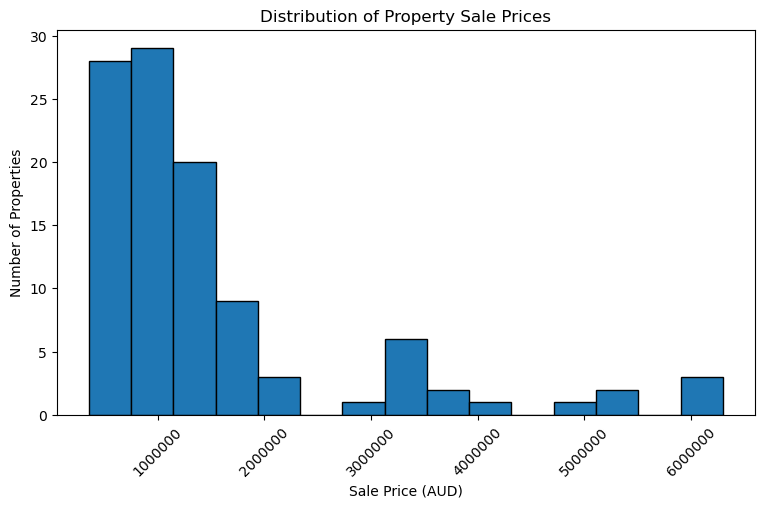

In [33]:
plt.figure(figsize=(9, 5))

plt.hist(df["Sale_Price"], bins=15, edgecolor="black")

plt.title("Distribution of Property Sale Prices")
plt.xlabel("Sale Price (AUD)")
plt.ylabel("Number of Properties")

plt.ticklabel_format(style="plain", axis="x")
plt.xticks(rotation=45)

plt.show()

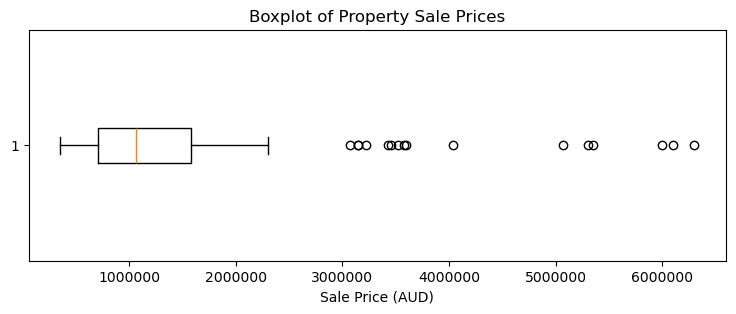

In [35]:
plt.figure(figsize=(9, 3))

plt.boxplot(df["Sale_Price"], vert=False)

plt.title("Boxplot of Property Sale Prices")
plt.xlabel("Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="x")

plt.show()

In [37]:
# inspecting highest and lowest prices 
highest_prices = df.nlargest(
    10, "Sale_Price"
)[
    ["Property_ID", "Suburb", "Property_Type",
     "Bedrooms", "Bathrooms", "Land_Size_m2", "Sale_Price"]
]

highest_prices

,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Land_Size_m2,Sale_Price
104,P105,Randwick,House,5,3,520,6300000
88,P089,Randwick,House,4,3,468,6100000
103,P104,Randwick,House,3,2,380,6000000
73,P074,Randwick,House,5,2,518,5350000
101,P102,Randwick,House,9,5,574,5300000
99,P100,Randwick,House,5,3,415,5065000
84,P085,Randwick,House,4,2,270,4035000
75,P076,Randwick,House,4,3,411,3600000
79,P080,Randwick,House,4,1,308,3575000
96,P097,Randwick,House,3,3,243,3520000


In [39]:
lowest_prices = df.nsmallest(
    10, "Sale_Price"
)[
    ["Property_ID", "Suburb", "Property_Type",
     "Bedrooms", "Bathrooms", "Land_Size_m2", "Sale_Price"]
]

lowest_prices

,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Land_Size_m2,Sale_Price
39,P040,Parramatta,Unit,1,1,95,355000
16,P017,Blacktown,Unit,2,1,84,419000
29,P030,Blacktown,Unit,2,2,97,420000
19,P020,Blacktown,Unit,2,2,122,435000
28,P029,Blacktown,Unit,2,2,111,440000
65,P066,Parramatta,Unit,1,1,63,442000
26,P027,Blacktown,Unit,2,2,124,450000
17,P018,Blacktown,Unit,2,1,99,460000
56,P057,Parramatta,Unit,2,1,113,470000
55,P056,Parramatta,Unit,2,1,1411,485000


In [41]:
# IQR potential outlier check 
Q1 = df["Sale_Price"].quantile(0.25)
Q3 = df["Sale_Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

price_outliers = df[
    (df["Sale_Price"] < lower_bound) |
    (df["Sale_Price"] > upper_bound)
]

print("Q1:", f"${Q1:,.0f}")
print("Q3:", f"${Q3:,.0f}")
print("IQR:", f"${IQR:,.0f}")
print("Lower bound:", f"${lower_bound:,.0f}")
print("Upper bound:", f"${upper_bound:,.0f}")
print("Number of potential price outliers:", len(price_outliers))

price_outliers[
    ["Property_ID", "Suburb", "Property_Type",
     "Bedrooms", "Bathrooms", "Parking",
     "Land_Size_m2", "Sale_Price"]
].sort_values("Sale_Price", ascending=False)

Q1: $705,000
Q3: $1,580,000
IQR: $875,000
Lower bound: $-607,500
Upper bound: $2,892,500
Number of potential price outliers: 16


,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Price
104,P105,Randwick,House,5,3,2,520,6300000
88,P089,Randwick,House,4,3,2,468,6100000
103,P104,Randwick,House,3,2,2,380,6000000
73,P074,Randwick,House,5,2,2,518,5350000
101,P102,Randwick,House,9,5,2,574,5300000
99,P100,Randwick,House,5,3,4,415,5065000
84,P085,Randwick,House,4,2,1,270,4035000
75,P076,Randwick,House,4,3,2,411,3600000
79,P080,Randwick,House,4,1,2,308,3575000
96,P097,Randwick,House,3,3,2,243,3520000


### Sale Price Distribution Observations

I found that property sale prices range from 355,000 dollars to 6.3 million dollars, with a median price of 1,062,500 dollars and a mean price of approximately 1.52 million dollars. The mean is considerably higher than the median, and the skewness value of 2.099 confirms that the sale price distribution is strongly right-skewed. This can also be seen in the histogram, where most properties are concentrated at the lower end of the price range while a smaller number of properties have much higher sale prices.

Using the IQR method, I identified 16 potential price outliers above the upper bound of 2,892,500 dollars. Most of these properties are houses located in Randwick, suggesting that many of the high values may reflect genuine differences in the housing markets rather than incorrect data. One unusual observation is P044 in Parramatta, which has 12 bedrooms, 6 bathrooms and 6 parking spaces and is classified as "Other". I will investigate unusual observations such as this further before deciding how they should be handled.

I also found that the ten lowest-priced properties are all units located in Blacktown or Parramatta, while the ten highest-priced properties are all houses in Randwick. This suggests that both location and property type may be important factors in explaining the large variation in sale prices.

## 2.3 Differences Between Suburbs

I next compared property prices across Blacktown, Parramatta and Randwick to understand how the housing markets differ between the three selected locations. I also examined the types of properties collected in each suburb, as differences in property type may partly explain differences in sale prices.

In [49]:
#Price statistics by suburb
suburb_price_summary = df.groupby("Suburb")["Sale_Price"].agg(
    Count="count",
    Mean="mean",
    Median="median",
    Minimum="min",
    Maximum="max"
)

suburb_price_summary

,Count,Mean,Median,Minimum,Maximum
Suburb,,,,,
Blacktown,35,1.026129e+06,1040000.0,419000,1900000
Parramatta,35,9.158857e+05,680000.0,355000,3425000
Randwick,35,2.609543e+06,1650000.0,785000,6300000


In [51]:
# Making the tables easier to read 
suburb_price_display = suburb_price_summary.copy()

for column in ["Mean", "Median", "Minimum", "Maximum"]:
    suburb_price_display[column] = suburb_price_display[column].map(
        lambda x: f"${x:,.0f}"
    )

suburb_price_display

,Count,Mean,Median,Minimum,Maximum
Suburb,,,,,
Blacktown,35,"$1,026,129","$1,040,000","$419,000","$1,900,000"
Parramatta,35,"$915,886","$680,000","$355,000","$3,425,000"
Randwick,35,"$2,609,543","$1,650,000","$785,000","$6,300,000"


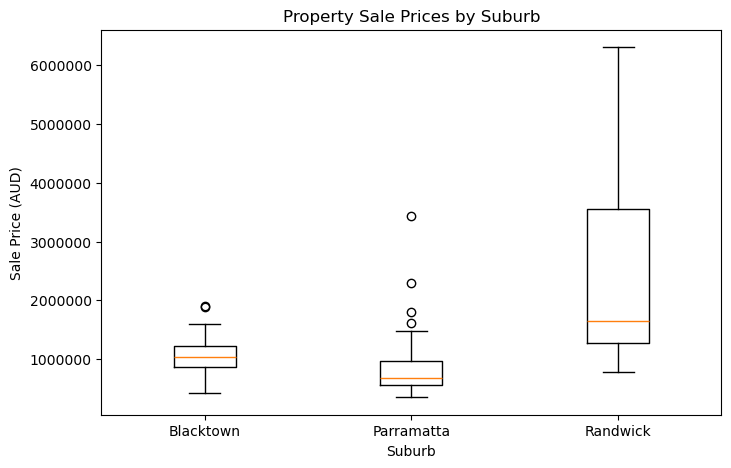

In [63]:
# Boxplot by surburb
suburbs = ["Blacktown", "Parramatta", "Randwick"]

price_by_suburb = [
    df.loc[df["Suburb"] == suburb, "Sale_Price"]
    for suburb in suburbs
]

plt.figure(figsize=(8, 5))

plt.boxplot(price_by_suburb, labels=suburbs)

plt.title("Property Sale Prices by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

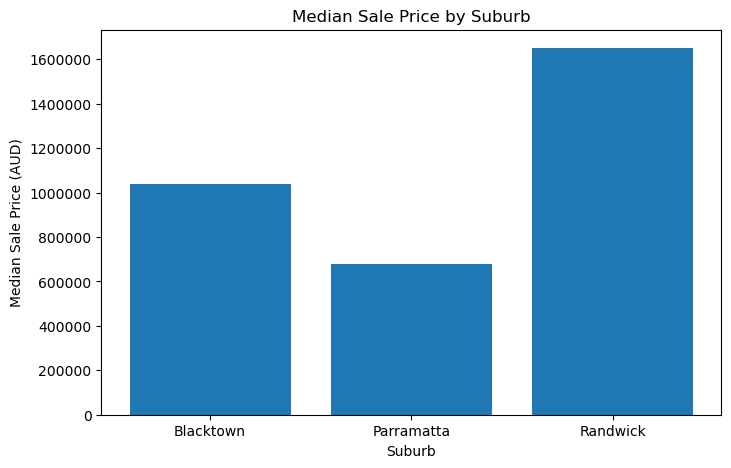

In [65]:
# Median price comparison
median_prices = (
    df.groupby("Suburb")["Sale_Price"]
    .median()
    .reindex(suburbs)
)

plt.figure(figsize=(8, 5))

plt.bar(median_prices.index, median_prices.values)

plt.title("Median Sale Price by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Median Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

In [67]:
# Property types within each suburb
property_type_by_suburb = pd.crosstab(
    df["Suburb"],
    df["Property_Type"]
)

property_type_by_suburb

Property_Type,House,Other,Townhouse,Unit
Suburb,,,,
Blacktown,26,1,0,8
Parramatta,5,1,2,27
Randwick,16,0,1,18


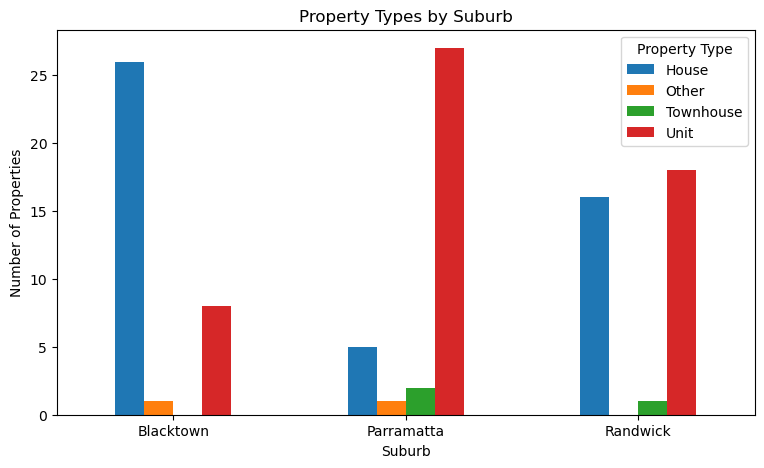

In [69]:
#visualising the property type mix
property_type_by_suburb.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Property Types by Suburb")
plt.xlabel("Suburb")
plt.ylabel("Number of Properties")
plt.xticks(rotation=0)
plt.legend(title="Property Type")

plt.show()

In [71]:
# Suburb and property type price summary
suburb_type_summary = (
    df.groupby(["Suburb", "Property_Type"])["Sale_Price"]
    .agg(["count", "median", "mean"])
    .round(0)
)

suburb_type_summary

count     median       mean
Suburb     Property_Type                             
Blacktown  House             26  1085000.0  1202135.0
           Other              1   865000.0   865000.0
           Unit               8   445000.0   474250.0
Parramatta House              5  1610000.0  1700000.0
           Other              1  3425000.0  3425000.0
           Townhouse          2  1184000.0  1184000.0
           Unit              27   660000.0   657889.0
Randwick   House             16  3587500.0  4188125.0
           Townhouse          1  2250000.0  2250000.0
           Unit              18  1270500.0  1226333.0

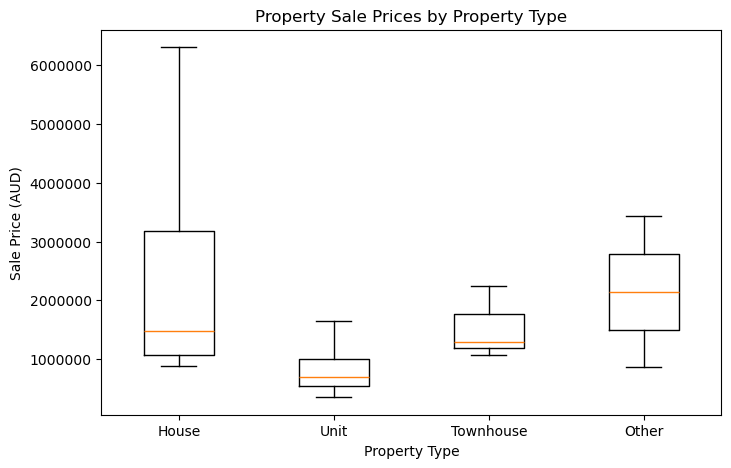

In [164]:
# Sale price distribution by property type

property_types = ["House", "Unit", "Townhouse", "Other"]

price_by_type = [
    df.loc[df["Property_Type"] == property_type, "Sale_Price"]
    for property_type in property_types
]

plt.figure(figsize=(8, 5))

plt.boxplot(price_by_type, labels=property_types)

plt.title("Property Sale Prices by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")

plt.show()

### Suburb Comparison Observations

I found clear differences in sale prices between the three suburbs. Randwick had the highest median sale price at 1.65 million dollars, compared with 1.04 million dollars in Blacktown and 680,000 dollars in Parramatta. Randwick also had a much wider price range, with prices reaching 6.3 million dollars. The boxplot shows that its property prices are generally higher and more variable than those in the other two suburbs.

I also found that the mix of property types differs considerably between suburbs. Blacktown contains mainly houses, with 26 houses and 8 units, while Parramatta contains mainly units, with 27 units and only 5 houses. Randwick has a more even mix of 16 houses and 18 units. This helps explain why Parramatta has a lower overall median price than Blacktown even though it is a more central location.

However, property type alone does not explain the suburb differences. When I compared the same property types, the median house price increased from approximately 1.09 million dollars in Blacktown to 1.61 million dollars in Parramatta and 3.59 million dollars in Randwick. Similarly, median unit prices were 445,000 dollars in Blacktown, 660,000 dollars in Parramatta and 1.27 million dollars in Randwick. This suggests that suburb or location is likely to be an important predictor of sale price, while property type also has an important influence.

## 2.4 Sale Price Trends Over Time

I next examined how sale prices varied over the period covered by the dataset. Since the properties were sold between October 2025 and September 2026, I explored both individual sale prices over time and monthly median prices. I also compared the trends between suburbs because changes in the types or locations of properties sold in each month could affect the overall pattern.

In [77]:
# Number of sales per month
# Creating a month variable for time-based analysis
df["Sale_Month"] = df["Sale_Date"].dt.to_period("M")

monthly_counts = df["Sale_Month"].value_counts().sort_index()

monthly_counts

Sale_Month
2025-10     1
2026-02     1
2026-03    12
2026-04     9
2026-05    20
2026-06    20
2026-07    25
2026-08    13
2026-09     4
Freq: M, Name: count, dtype: int64

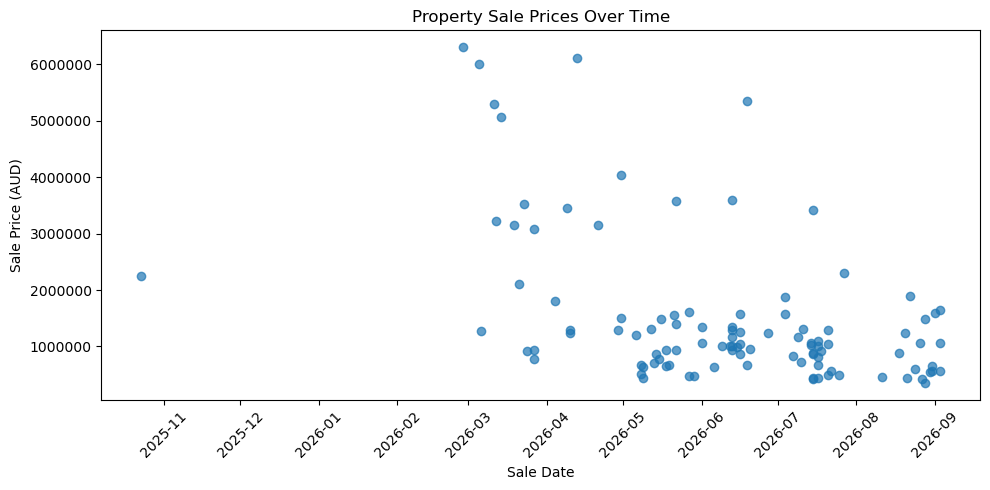

In [79]:
# Individual sale prices over time
plt.figure(figsize=(10, 5))

plt.scatter(df["Sale_Date"], df["Sale_Price"], alpha=0.7)

plt.title("Property Sale Prices Over Time")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

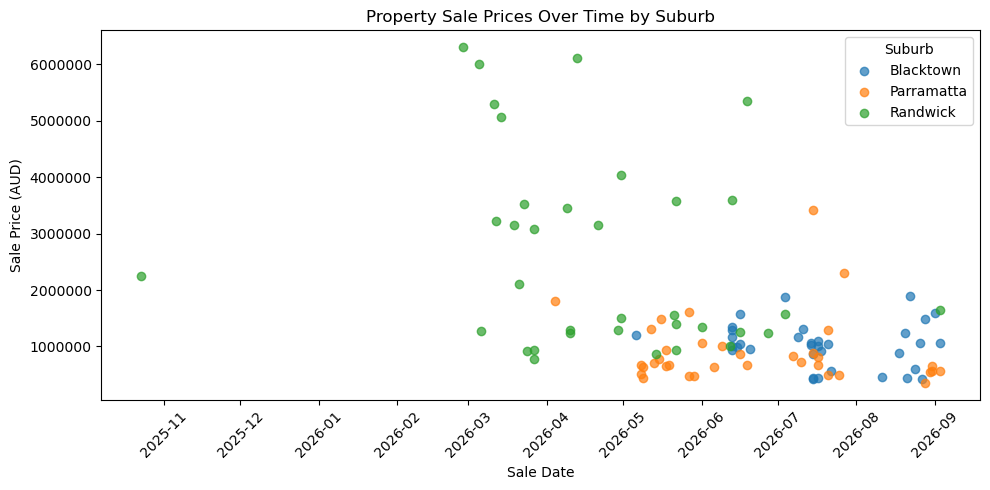

In [81]:
# Individual sales by suburb
plt.figure(figsize=(10, 5))

for suburb in ["Blacktown", "Parramatta", "Randwick"]:
    suburb_data = df[df["Suburb"] == suburb]
    
    plt.scatter(
        suburb_data["Sale_Date"],
        suburb_data["Sale_Price"],
        label=suburb,
        alpha=0.7
    )

plt.title("Property Sale Prices Over Time by Suburb")
plt.xlabel("Sale Date")
plt.ylabel("Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.legend(title="Suburb")

plt.tight_layout()
plt.show()

In [83]:
# Monthly price statistics
monthly_price_summary = (
    df.groupby("Sale_Month")["Sale_Price"]
    .agg(
        Count="count",
        Mean="mean",
        Median="median"
    )
)

monthly_price_summary

,Count,Mean,Median
Sale_Month,,,
2025-10,1,2.250000e+06,2250000.0
2026-02,1,6.300000e+06,6300000.0
2026-03,12,2.946167e+06,3112500.0
2026-04,9,2.651333e+06,1800000.0
2026-05,20,1.045200e+06,817500.0
2026-06,20,1.418000e+06,1054000.0
2026-07,25,1.071960e+06,925000.0
2026-08,13,8.142692e+05,600000.0
2026-09,4,1.222500e+06,1335000.0


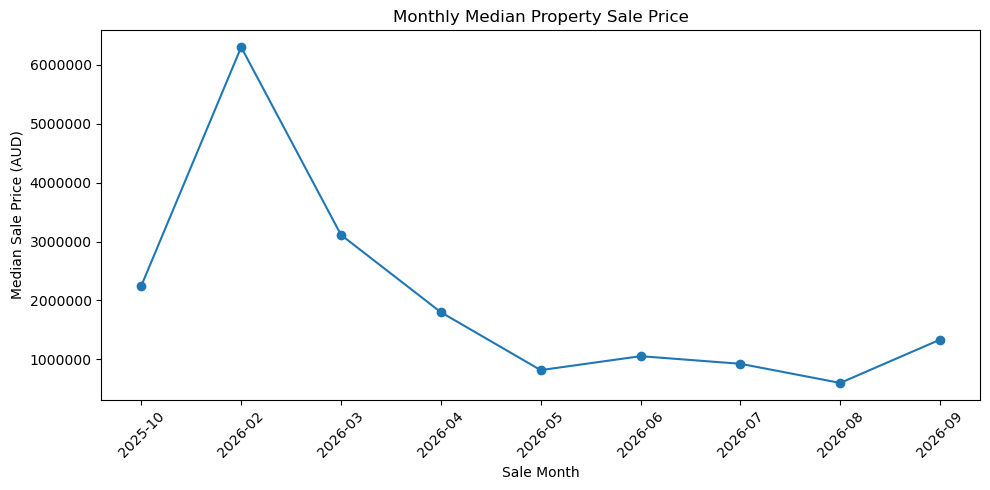

In [85]:
# Monthly median sale price
monthly_median = df.groupby("Sale_Month")["Sale_Price"].median()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_median.index.astype(str),
    monthly_median.values,
    marker="o"
)

plt.title("Monthly Median Property Sale Price")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [87]:
# Monthly median by suburb
monthly_suburb_median = (
    df.groupby(["Sale_Month", "Suburb"])["Sale_Price"]
    .median()
    .unstack()
)

monthly_suburb_median

Suburb,Blacktown,Parramatta,Randwick
Sale_Month,,,
2025-10,NaN,NaN,2250000.0
2026-02,NaN,NaN,6300000.0
2026-03,NaN,NaN,3112500.0
2026-04,NaN,1800000.0,2325000.0
2026-05,1200000.0,674000.0,1400000.0
2026-06,1040000.0,870000.0,1307500.0
2026-07,1017499.5,822500.0,1580000.0
2026-08,880000.0,554500.0,NaN
2026-09,1335000.0,570000.0,1650000.0


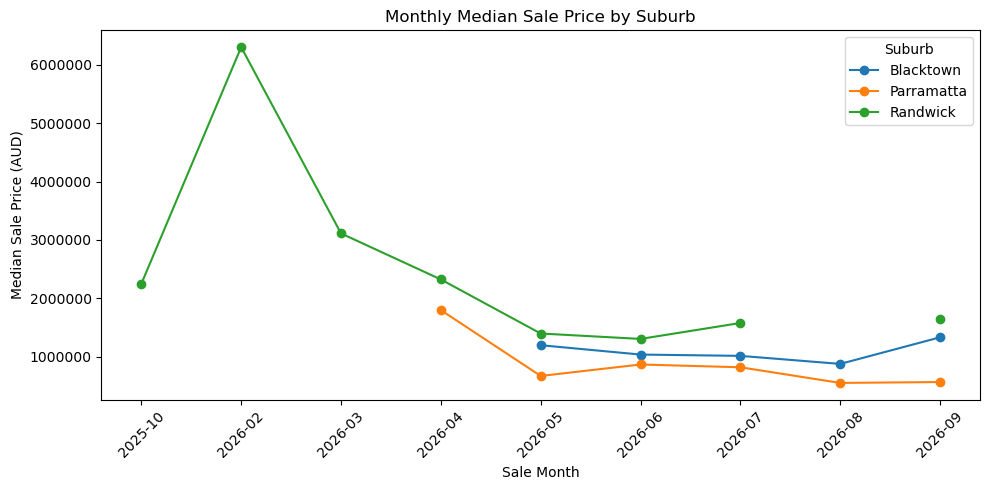

In [89]:
monthly_suburb_median.index = monthly_suburb_median.index.astype(str)

plt.figure(figsize=(10, 5))

for suburb in monthly_suburb_median.columns:
    plt.plot(
        monthly_suburb_median.index,
        monthly_suburb_median[suburb],
        marker="o",
        label=suburb
    )

plt.title("Monthly Median Sale Price by Suburb")
plt.xlabel("Sale Month")
plt.ylabel("Median Sale Price (AUD)")

plt.ticklabel_format(style="plain", axis="y")
plt.xticks(rotation=45)
plt.legend(title="Suburb")

plt.tight_layout()
plt.show()

In [91]:
# Sales per month and suburb
monthly_suburb_counts = pd.crosstab(
    df["Sale_Month"],
    df["Suburb"]
)

monthly_suburb_counts

Suburb,Blacktown,Parramatta,Randwick
Sale_Month,,,
2025-10,0,0,1
2026-02,0,0,1
2026-03,0,0,12
2026-04,0,1,8
2026-05,1,14,5
2026-06,9,5,6
2026-07,14,10,1
2026-08,9,4,0
2026-09,2,1,1


### Time Trend Observations

The overall monthly median prices varied considerably across the period, but I found that this pattern was strongly influenced by the composition of the properties collected each month. For example, all 12 properties sold in March were from Randwick, while most observations in May were from Parramatta. The very high median in February was also based on only one Randwick property, so it should not be interpreted as evidence of a market-wide price increase.

When I compared the suburbs separately, Randwick generally remained the highest-priced market, while Blacktown and Parramatta had lower sale prices. Some variation was visible within each suburb over time, but the number of observations was uneven and several suburb-month combinations contained very few properties. Therefore, I could not identify a reliable overall price trend from this dataset. The observed monthly changes appear to reflect differences in the suburbs and properties represented in each month as well as possible changes over time.

This highlights an important limitation of the manually collected dataset. It covers a relatively short period and the sales are not evenly distributed across time or suburbs, so the time-based results should be interpreted cautiously.


## 2.5 Relationships Between Property Features and Sale Price

I next explored the relationships between the numerical property characteristics and sale price. This was used to determine whether features such as bedrooms, bathrooms, parking and land size showed meaningful relationships with property value before feature engineering and model development.

In [95]:
# Correlation between numerical property features and sale price
numeric_features = [
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land_Size_m2",
    "Sale_Price"
]

correlation_matrix = df[numeric_features].corr()

correlation_matrix.round(3)

,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Price
Bedrooms,1.000,0.785,0.702,-0.017,0.567
Bathrooms,0.785,1.000,0.584,0.066,0.501
Parking,0.702,0.584,1.000,0.013,0.278
Land_Size_m2,-0.017,0.066,0.013,1.000,0.003
Sale_Price,0.567,0.501,0.278,0.003,1.000


In [97]:
price_correlations = (
    correlation_matrix["Sale_Price"]
    .drop("Sale_Price")
    .sort_values(ascending=False)
)

price_correlations

Bedrooms        0.566678
Bathrooms       0.500638
Parking         0.278054
Land_Size_m2    0.002939
Name: Sale_Price, dtype: float64

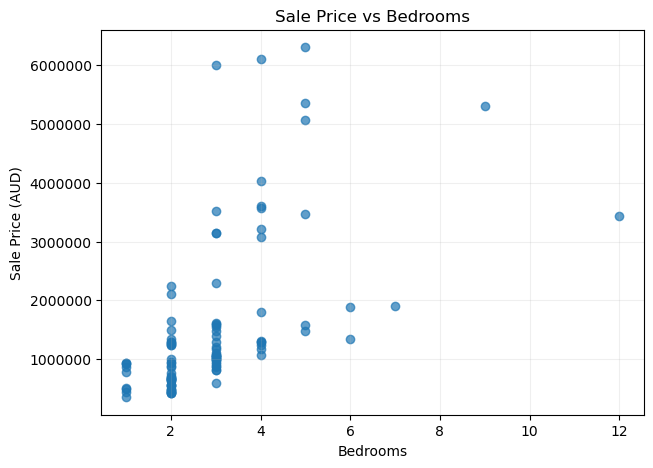

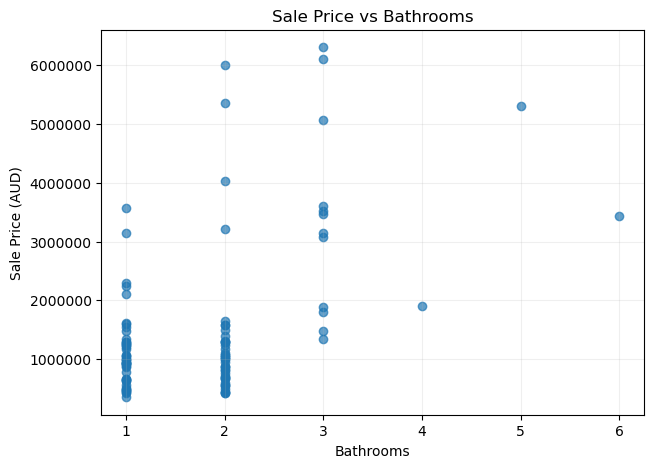

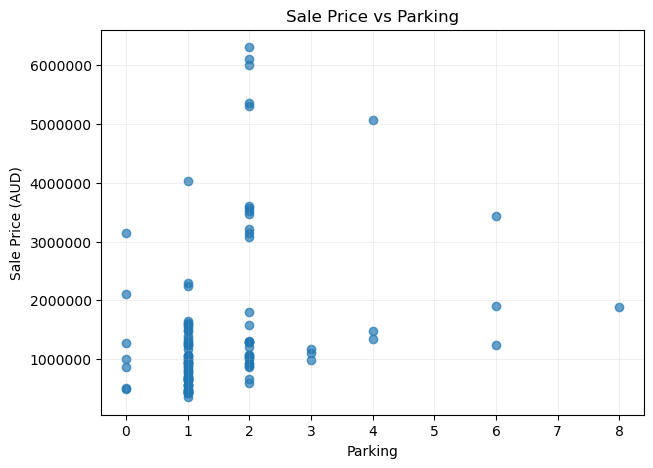

In [99]:
# Sale price relationships with bedrooms, bathrooms and parking
features = ["Bedrooms", "Bathrooms", "Parking"]

for feature in features:
    plt.figure(figsize=(7, 5))
    
    plt.scatter(
        df[feature],
        df["Sale_Price"],
        alpha=0.7
    )
    
    plt.title(f"Sale Price vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("Sale Price (AUD)")
    plt.ticklabel_format(style="plain", axis="y")
    plt.grid(alpha=0.2)
    plt.show()

In [101]:
# Median sale price for each feature value
for feature in ["Bedrooms", "Bathrooms", "Parking"]:
    summary = (
        df.groupby(feature)["Sale_Price"]
        .agg(["count", "median", "mean"])
        .round(0)
    )
    
    print(f"\nSale Price by {feature}")
    display(summary)


Sale Price by Bedrooms


,count,median,mean
Bedrooms,,,
1,9,785000.0,694444.0
2,40,680000.0,872525.0
3,32,1066500.0,1508828.0
4,13,1800000.0,2522308.0
5,6,4262500.0,3872500.0
6,2,1610500.0,1610500.0
7,1,1900000.0,1900000.0
9,1,5300000.0,5300000.0
12,1,3425000.0,3425000.0



Sale Price by Bathrooms


,count,median,mean
Bathrooms,,,
1,47,985000.0,1121564.0
2,43,1000000.0,1283605.0
3,12,3305000.0,3397583.0
4,1,1900000.0,1900000.0
5,1,5300000.0,5300000.0
6,1,3425000.0,3425000.0



Sale Price by Parking


,count,median,mean
Parking,,,
0,7,1000000.0,1344714.0
1,58,875000.0,996250.0
2,30,1305500.0,2417600.0
3,3,1100000.0,1085000.0
4,3,1480000.0,2628333.0
6,3,1900000.0,2186667.0
8,1,1881000.0,1881000.0


In [103]:
# Land size distribution by property type
land_summary = (
    df.groupby("Property_Type")["Land_Size_m2"]
    .agg(["count", "min", "median", "mean", "max"])
    .round(1)
)

land_summary

,count,min,median,mean,max
Property_Type,,,,,
House,47,132,556.0,638.2,5478
Other,2,217,560.0,560.0,903
Townhouse,3,173,196.0,217.7,284
Unit,53,62,110.0,655.3,7142


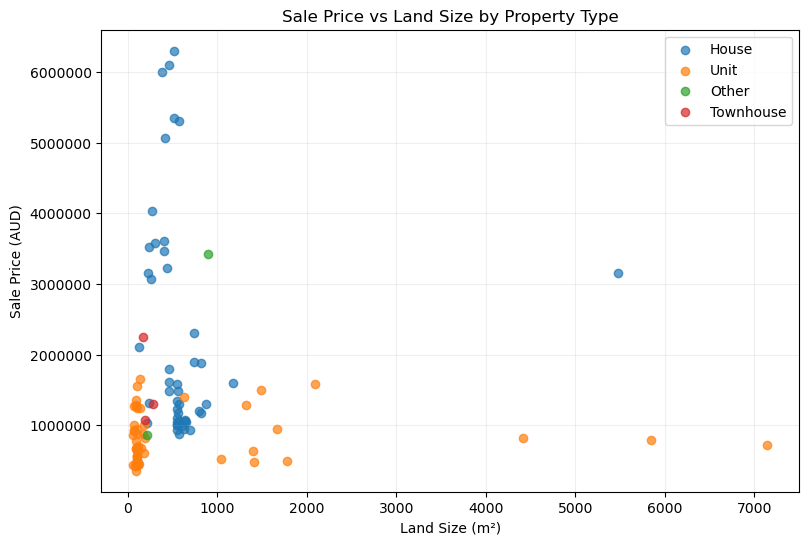

In [105]:
# Sale price vs land size by property type
plt.figure(figsize=(9, 6))

for property_type in df["Property_Type"].unique():
    subset = df[df["Property_Type"] == property_type]
    
    plt.scatter(
        subset["Land_Size_m2"],
        subset["Sale_Price"],
        alpha=0.7,
        label=property_type
    )

plt.title("Sale Price vs Land Size by Property Type")
plt.xlabel("Land Size (m²)")
plt.ylabel("Sale Price (AUD)")
plt.ticklabel_format(style="plain", axis="y")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [107]:
# Correlation between land size and sale price within each property type
for property_type in df["Property_Type"].unique():
    subset = df[df["Property_Type"] == property_type]
    
    if len(subset) >= 3:
        correlation = subset["Land_Size_m2"].corr(subset["Sale_Price"])
        print(
            f"{property_type}: "
            f"n = {len(subset)}, "
            f"correlation = {correlation:.3f}"
        )

House: n = 47, correlation = -0.012
Unit: n = 53, correlation = 0.040
Townhouse: n = 3, correlation = -0.510


### Numerical Feature Observations

Bedrooms showed the strongest numerical relationship with sale price, with a correlation of 0.567, followed by bathrooms at 0.501. The grouped results also showed that median prices generally increased from two- to five-bedroom properties. However, the higher bedroom and bathroom categories contained very few observations, so these values should be interpreted cautiously. Parking had a weaker correlation of 0.278 and did not show a consistent increase in median price as the number of parking spaces increased.

Land size produced an unexpected result. Its overall correlation with sale price was only 0.003. I investigated this further by separating properties by type. Houses had a correlation of -0.012 and units had a correlation of 0.040, showing little linear relationship within this dataset. I also found that unit land sizes were highly variable, with a median of 110 m^2 but a maximum of 7,142 m^2. This suggests that the recorded land-size field may not represent the same concept across property types, as some unit listings may report the land area of the wider strata or development site rather than the individual unit. Therefore, I would be cautious about using raw land size directly as a predictor without accounting for property type.

## 2.6 Unusual Observations and Outliers

In [111]:
# Identifying sale price outliers using the IQR method
Q1 = df["Sale_Price"].quantile(0.25)
Q3 = df["Sale_Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: ${Q1:,.0f}")
print(f"Q3: ${Q3:,.0f}")
print(f"IQR: ${IQR:,.0f}")
print(f"Lower bound: ${lower_bound:,.0f}")
print(f"Upper bound: ${upper_bound:,.0f}")

Q1: $705,000
Q3: $1,580,000
IQR: $875,000
Lower bound: $-607,500
Upper bound: $2,892,500


In [113]:
price_outliers = df[
    (df["Sale_Price"] < lower_bound) |
    (df["Sale_Price"] > upper_bound)
][
    [
        "Property_ID",
        "Suburb",
        "Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Parking",
        "Land_Size_m2",
        "Sale_Price",
        "Address"
    ]
].sort_values("Sale_Price", ascending=False)

price_outliers

,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Price,Address
104,P105,Randwick,House,5,3,2,520,6300000,"9 Glen Avenue, Randwick"
88,P089,Randwick,House,4,3,2,468,6100000,"110 Oberon, Randwick"
103,P104,Randwick,House,3,2,2,380,6000000,"2 Sydney Street, Randwick"
73,P074,Randwick,House,5,2,2,518,5350000,"3 Glen Avenue, Randwick"
101,P102,Randwick,House,9,5,2,574,5300000,"224 Alison Road, Randwick"
99,P100,Randwick,House,5,3,4,415,5065000,"6 Stanley Street, Randwick"
84,P085,Randwick,House,4,2,1,270,4035000,"25 Wentworth Street, Randwick"
75,P076,Randwick,House,4,3,2,411,3600000,"8 Dudley Street, Randwick"
79,P080,Randwick,House,4,1,2,308,3575000,"3 Carter Street, Randwick"
96,P097,Randwick,House,3,3,2,243,3520000,"8 Fraser Street, Randwick"


In [115]:
# Identifying sale price outliers within each suburb
suburb_outliers = []

for suburb in df["Suburb"].unique():
    subset = df[df["Suburb"] == suburb]
    
    Q1_suburb = subset["Sale_Price"].quantile(0.25)
    Q3_suburb = subset["Sale_Price"].quantile(0.75)
    IQR_suburb = Q3_suburb - Q1_suburb
    
    lower_suburb = Q1_suburb - 1.5 * IQR_suburb
    upper_suburb = Q3_suburb + 1.5 * IQR_suburb
    
    print(f"{suburb}")
    print(f"  Q1: ${Q1_suburb:,.0f}")
    print(f"  Q3: ${Q3_suburb:,.0f}")
    print(f"  Upper bound: ${upper_suburb:,.0f}")
    
    outliers = subset[
        (subset["Sale_Price"] < lower_suburb) |
        (subset["Sale_Price"] > upper_suburb)
    ].copy()
    
    suburb_outliers.append(outliers)

suburb_outliers = pd.concat(suburb_outliers)

suburb_outliers[
    [
        "Property_ID",
        "Suburb",
        "Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Parking",
        "Land_Size_m2",
        "Sale_Price",
        "Address"
    ]
].sort_values(["Suburb", "Sale_Price"], ascending=[True, False])

Blacktown
  Q1: $872,500
  Q3: $1,217,500
  Upper bound: $1,735,000
Parramatta
  Q1: $569,500
  Q3: $973,000
  Upper bound: $1,578,250
Randwick
  Q1: $1,270,500
  Q3: $3,547,500
  Upper bound: $6,963,000


,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Sale_Price,Address
4,P005,Blacktown,House,7,4,6,739,1900000,"13 Lancaster Street, Blacktown"
6,P007,Blacktown,House,6,3,8,817,1881000,"52a Allawah Street, Blacktown"
43,P044,Parramatta,Other,12,6,6,903,3425000,"37A Sutherland rOAD, Parramatta"
47,P048,Parramatta,House,3,1,1,739,2300000,"124 Thomas Street, Parramatta"
69,P070,Parramatta,House,4,3,2,461,1800000,"13 Morton Street, Parramatta"
57,P058,Parramatta,House,3,1,1,461,1610000,"11 Pemberton Street, Parramatta"


### Outlier Observations

Using the IQR method on the overall sale price distribution, properties above 2,892,500 dollars were initially identified as potential outliers. This resulted in 16 properties being flagged, with 15 located in Randwick. However, because the three suburbs represent substantially different housing markets, I found that applying a single threshold across the entire dataset was potentially misleading.

I therefore repeated the IQR analysis separately within each suburb. This identified two unusually high-priced properties in Blacktown and four in Parramatta, while no Randwick properties were classified as outliers relative to the Randwick price distribution. This shows that the high Randwick prices are characteristic of that suburb rather than necessarily being abnormal observations.

The identified properties were retained because they represent genuine sales rather than obvious data errors. One particularly unusual observation is P044 in Parramatta, which represents an entire block of apartments and therefore differs considerably from a typical residential property. Retaining these observations preserves genuine variation in the housing market, although their influence on model performance will need to be considered during modelling and prediction-error analysis.

## 2.7 Feature Engineering

Based on the exploratory analysis, I engineered additional features that could provide the models with more meaningful information about the properties. I aimed to keep the features interpretable and related to factors that could reasonably influence housing prices, rather than creating a large number of unnecessary variables.

The earlier analysis showed that location, property type and property characteristics are important, while some raw variables also require careful treatment. In particular, land size was not directly comparable across property types because large land values for some units appear to represent the overall strata site rather than the individual apartment area. I therefore considered this issue when preparing the features for modelling.

### 2.7.1 Feature 1: Days_Since_First_Sale 

In [121]:
# Creating a numerical time feature from the sale date
first_sale_date = df["Sale_Date"].min()

df["Days_Since_First_Sale"] = (
    df["Sale_Date"] - first_sale_date
).dt.days

df[
    ["Sale_Date", "Days_Since_First_Sale"]
].head(10)

,Sale_Date,Days_Since_First_Sale
0,2026-09-03,315
1,2026-09-01,313
2,2026-08-28,309
3,2026-08-26,307
4,2026-08-22,303
5,2026-05-06,195
6,2026-07-04,254
7,2026-06-20,240
8,2026-06-16,236
9,2026-06-16,236


In [123]:
print("First sale date:", df["Sale_Date"].min())
print("Last sale date:", df["Sale_Date"].max())
print(
    "Range of Days_Since_First_Sale:",
    df["Days_Since_First_Sale"].min(),
    "to",
    df["Days_Since_First_Sale"].max()
)

First sale date: 2025-10-23 00:00:00
Last sale date: 2026-09-03 00:00:00
Range of Days_Since_First_Sale: 0 to 315


### 2.7.2 Feature 2: Property description indicators

In [126]:
# Creating interpretable features from the property descriptions
text = df["Property_Description"].fillna("").str.lower()

keyword_groups = {
    "Near_Transport": [
        "station", "train", "bus", "metro", "light rail"
    ],
    "Near_School": [
        "school", "college", "university"
    ],
    "Near_Shops": [
        "shops", "shopping", "retail"
    ],
    "Near_Park": [
        "park", "reserve", "recreation"
    ],
    "Renovated": [
        "renovated", "updated", "modernised", "modernized"
    ],
    "Development_Potential": [
        "development", "develop", "duplex", "stca"
    ],
    "Granny_Flat": [
        "granny flat", "secondary dwelling"
    ],
    "Premium_Feature": [
        "beach", "ocean", "coastal", "view", "views", "waterfront"
    ]
}

for feature, keywords in keyword_groups.items():
    pattern = "|".join(keywords)
    df[feature] = text.str.contains(
        pattern,
        regex=True
    ).astype(int)

In [128]:
description_features = list(keyword_groups.keys())

feature_counts = pd.DataFrame({
    "Count_1": df[description_features].sum(),
    "Percentage": (
        df[description_features].mean() * 100
    ).round(1)
})

feature_counts


,Count_1,Percentage
Near_Transport,60,57.1
Near_School,57,54.3
Near_Shops,61,58.1
Near_Park,48,45.7
Renovated,12,11.4
Development_Potential,15,14.3
Granny_Flat,6,5.7
Premium_Feature,35,33.3


In [130]:
df[
    ["Property_ID", "Property_Description"] + description_features
].head(10)

,Property_ID,Property_Description,Near_Transport,Near_School,Near_Shops,Near_Park,Renovated,Development_Potential,Granny_Flat,Premium_Feature
0,P001,Spacious Family Residence with Development Pot...,1,1,1,0,0,1,0,0
1,P002,A rare and strategic opportunity awaits at 17 ...,1,0,1,0,0,1,0,0
2,P003,Proudly presented to market by Blacktown's awa...,0,1,1,0,1,0,1,0
3,P004,Beautifully renovated throughout and designed ...,0,1,1,1,1,0,0,0
4,P005,"Custom built and only four years young, this a...",1,1,0,0,0,1,1,0
5,P006,Peacefully positioned in a quiet cul-de-sac wi...,0,0,0,0,0,1,0,0
6,P007,Calling all large or extended families and ast...,1,1,1,0,0,0,0,0
7,P008,Building and Pest report and Contract for Sale...,1,1,1,0,0,1,1,1
8,P009,This oversized three-bedroom family home sitti...,1,1,1,0,0,0,0,0
9,P010,"Luxury, Space, Lifestyle, rare find is this ov...",1,1,1,0,0,0,0,0


#### Property Description Feature Engineering:
I created eight binary features from the property descriptions to capture potentially useful information that was not represented by the original structured variables. The indicators represent mentions of transport, schools, shops, parks, renovation, development potential, granny flats and premium location features. The frequencies show sufficient variation across most indicators, although granny flats, renovations and development potential are less commonly mentioned. These variables should be interpreted as features mentioned in the collected property descriptions, rather than proof that the characteristic is present or absent in reality, since listing descriptions are not standardised.

### 2.7.3 Feature 3: House Land Size

Exploratory analysis showed that `Land_Size_m2` is not directly comparable across property types. In particular, some unit listings report very large land areas that appear to represent the overall strata or development site rather than the individual apartment area. To avoid treating these values as equivalent to house land size, I created `House_Land_Size_m2`. This retains the recorded land size for houses and assigns 0 to non-house properties. Property type remains available separately, allowing the model to distinguish between houses and other property types.

In [135]:
# Creating a house-specific land size feature
df["House_Land_Size_m2"] = np.where(
    df["Property_Type"] == "House",
    df["Land_Size_m2"],
    0
)

df[
    ["Property_ID", "Property_Type", "Land_Size_m2", "House_Land_Size_m2"]
].head(15)

,Property_ID,Property_Type,Land_Size_m2,House_Land_Size_m2
0,P001,House,638,638
1,P002,House,1182,1182
2,P003,House,563,563
3,P004,House,575,575
4,P005,House,739,739
5,P006,House,796,796
6,P007,House,817,817
7,P008,House,626,626
8,P009,House,651,651
9,P010,House,556,556


In [137]:
import numpy as np

In [139]:
df.groupby("Property_Type")[
    ["Land_Size_m2", "House_Land_Size_m2"]
].agg(["count", "median", "mean", "max"]).round(1)

Land_Size_m2                     House_Land_Size_m2         \
                     count median   mean   max              count median   
Property_Type                                                              
House                   47  556.0  638.2  5478                 47  556.0   
Other                    2  560.0  560.0   903                  2    0.0   
Townhouse                3  196.0  217.7   284                  3    0.0   
Unit                    53  110.0  655.3  7142                 53    0.0   

                            
                mean   max  
Property_Type               
House          638.2  5478  
Other            0.0     0  
Townhouse        0.0     0  
Unit             0.0     0

In [141]:
house_data = df[df["Property_Type"] == "House"]

print(
    "Correlation between house land size and sale price:",
    round(house_data["House_Land_Size_m2"].corr(house_data["Sale_Price"]), 3)
)

print(
    "Number of non-house properties with House_Land_Size_m2 != 0:",
    (df.loc[df["Property_Type"] != "House", "House_Land_Size_m2"] != 0).sum()
)

Correlation between house land size and sale price: -0.012
Number of non-house properties with House_Land_Size_m2 != 0: 0


### 2.7.4 Feature 4: Total_Rooms

Bedrooms and bathrooms individually showed positive relationships with sale price during the exploratory analysis. I therefore created `Total_Rooms` by adding the number of bedrooms and bathrooms. This provides a simple measure of the overall internal room capacity of each property while retaining the original bedroom and bathroom variables for modelling.

In [146]:
# Creating a combined room feature
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]

df[
    ["Property_ID", "Bedrooms", "Bathrooms", "Total_Rooms", "Sale_Price"]
].head(10)

,Property_ID,Bedrooms,Bathrooms,Total_Rooms,Sale_Price
0,P001,4,1,5,1070000
1,P002,3,1,4,1600000
2,P003,5,3,8,1480000
3,P004,3,1,4,1062500
4,P005,7,4,11,1900000
5,P006,3,1,4,1200000
6,P007,6,3,9,1881000
7,P008,3,1,4,950000
8,P009,3,2,5,1040000
9,P010,5,2,7,1580000


In [148]:
# Creating a combined room feature
df["Total_Rooms"] = df["Bedrooms"] + df["Bathrooms"]

df[
    ["Property_ID", "Bedrooms", "Bathrooms", "Total_Rooms", "Sale_Price"]
].head(10)

,Property_ID,Bedrooms,Bathrooms,Total_Rooms,Sale_Price
0,P001,4,1,5,1070000
1,P002,3,1,4,1600000
2,P003,5,3,8,1480000
3,P004,3,1,4,1062500
4,P005,7,4,11,1900000
5,P006,3,1,4,1200000
6,P007,6,3,9,1881000
7,P008,3,1,4,950000
8,P009,3,2,5,1040000
9,P010,5,2,7,1580000


In [150]:
print(
    "Correlation between Total_Rooms and Sale_Price:",
    round(df["Total_Rooms"].corr(df["Sale_Price"]), 3)
)

df["Total_Rooms"].describe()

Correlation between Total_Rooms and Sale_Price: 0.572


count    105.00000
mean       4.67619
std        2.35133
min        2.00000
25%        3.00000
50%        4.00000
75%        5.00000
max       18.00000
Name: Total_Rooms, dtype: float64

### 2.7.5 Verifying all engineered features together

In [162]:
# Reviewing all engineered features

engineered_features = [
    "Days_Since_First_Sale",
    "Near_Transport",
    "Near_School",
    "Near_Shops",
    "Near_Park",
    "Renovated",
    "Development_Potential",
    "Granny_Flat",
    "Premium_Feature",
    "House_Land_Size_m2",
    "Total_Rooms"
]

df[engineered_features].describe().round(2).T


,count,mean,std,min,25%,50%,75%,max
Days_Since_First_Sale,105.0,229.70,55.86,0.0,198.0,233.0,267.0,315.0
Near_Transport,105.0,0.57,0.50,0.0,0.0,1.0,1.0,1.0
Near_School,105.0,0.54,0.50,0.0,0.0,1.0,1.0,1.0
Near_Shops,105.0,0.58,0.50,0.0,0.0,1.0,1.0,1.0
Near_Park,105.0,0.46,0.50,0.0,0.0,0.0,1.0,1.0
Renovated,105.0,0.11,0.32,0.0,0.0,0.0,0.0,1.0
Development_Potential,105.0,0.14,0.35,0.0,0.0,0.0,0.0,1.0
Granny_Flat,105.0,0.06,0.23,0.0,0.0,0.0,0.0,1.0
Premium_Feature,105.0,0.33,0.47,0.0,0.0,0.0,1.0,1.0
House_Land_Size_m2,105.0,285.66,590.57,0.0,0.0,0.0,556.0,5478.0


In [157]:
# Checking engineered features for missing values
print("Missing values:")
print(df[engineered_features].isnull().sum())

print("\nNumber of engineered features:", len(engineered_features))
print("Dataset shape after feature engineering:", df.shape)

Missing values:
Days_Since_First_Sale    0
Near_Transport           0
Near_School              0
Near_Shops               0
Near_Park                0
Renovated                0
Development_Potential    0
Granny_Flat              0
Premium_Feature          0
House_Land_Size_m2       0
Total_Rooms              0
dtype: int64

Number of engineered features: 11
Dataset shape after feature engineering: (105, 26)


### Feature Engineering Reflection

The feature engineering process generally aligned with my initial understanding of the factors that may influence housing prices. I expected location and property characteristics to be important, so I retained suburb and property type while creating additional features from the available information. Total_Rooms was created to represent the overall size of the property's living accommodation, while `Days_Since_First_Sale` captures possible changes in the market over the collection period. I also created `House_Land_Size_m2` because the exploratory analysis showed that the meaning of land size was inconsistent across property types, particularly for units where the reported value may represent the entire strata site rather than the individual property.

The property descriptions also contained information that was not captured by the structured variables. I therefore extracted indicators for features such as nearby transport, schools, shops and parks, renovation, development potential, granny flats and premium features. These engineered variables broadly reflect factors I would consider when evaluating a property myself. However, they should be interpreted cautiously because a feature being absent from a description does not necessarily mean that it is absent in reality. Overall, the engineering process expanded the dataset while remaining consistent with the factors identified during the initial exploration.

# 3. Model Development and Evaluation


## 3.1 Model Selection and Initial Expectations

Three regression models were chosen to represent different model techniques: Ridge Regression, Random Forest Regression, and Gradient Boosting Regression

**Ridge Regression** was included as a regularised linear model. There are several features (variables) in the data set which are related to each other: the count of rooms in a unit (bedrooms), bathrooms, or Total_Rooms are all connected in some way, so regularisation could help decrease errors caused by correlated features. In addition, Ridge Regression is fairly straightforward and can be used to explain results fairly well. But, since housing prices are affected by nonlinear relationships and interactions among various house characteristics, my linear model may be so simple that it fails to fit the real relationship properly.

**Random Forest Regression** was another modeling technique used, this type of model can find the relations between the variables in the data in a form that is nonlinear without being restricted to certain relations, manually or otherwise. It is very likely that, in a housing market, different effects on the market price of the feature (e.g. bedrooms or property type) depend on several factors like area, among others. A drawback here is that the data set has a sample size of 105 records. So if the forest is too complicated then it may still be possible that all of the model is just memorising the very small training dataset, therefore overfitting.

The decision for **Gradient Boosting Regression** was primarily due to the capability of such tree-based methods for nonlinear pattern detection, similar to Random Forest. Where Random Forest trains each tree independently of the others, Gradient Boosting trains trees by using mistakes made in previous trees, so each new tree focuses on correcting the errors of the previous one. This kind of process is particularly beneficial in terms of accuracy for structured tabular data but there is always a risk that if the model complexity is increased too much without data size being increased, overfitting will happen.

As for model performance after training, I anticipate **Gradient Boosting Regression** will be the best of them and then Random Forest Regression coming next. While Ridge Regression has been a great reference point by being linear itself, there are situations in which it might actually miss on a lot more information. That's because linear models, by their nature, are quite poor at finding relationships that are complicated or have many interactions such as housing data features and prices.


In [168]:
# Reviewing the available columns before modelling
print(df.columns.tolist())

print("\nTotal number of columns:", len(df.columns))

['Property_ID', 'Suburb', 'Postcode', 'Property_Type', 'Bedrooms', 'Bathrooms', 'Parking', 'Land_Size_m2', 'Sale_Price', 'Sale_Date', 'Address', 'Property_Description', 'Source', 'Source_URL', 'Sale_Month', 'Days_Since_First_Sale', 'Near_Transport', 'Near_School', 'Near_Shops', 'Near_Park', 'Renovated', 'Development_Potential', 'Granny_Flat', 'Premium_Feature', 'House_Land_Size_m2', 'Total_Rooms']

Total number of columns: 26


In [170]:
# Selecting predictors for modelling

numeric_features = [
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Days_Since_First_Sale",
    "House_Land_Size_m2",
    "Total_Rooms",
    "Near_Transport",
    "Near_School",
    "Near_Shops",
    "Near_Park",
    "Renovated",
    "Development_Potential",
    "Granny_Flat",
    "Premium_Feature"
]

categorical_features = [
    "Suburb",
    "Property_Type"
]

model_features = numeric_features + categorical_features

X = df[model_features]
y = df["Sale_Price"]

print("Predictor shape:", X.shape)
print("Target shape:", y.shape)
print("\nPredictors used:")
print(model_features)

Predictor shape: (105, 16)
Target shape: (105,)

Predictors used:
['Bedrooms', 'Bathrooms', 'Parking', 'Days_Since_First_Sale', 'House_Land_Size_m2', 'Total_Rooms', 'Near_Transport', 'Near_School', 'Near_Shops', 'Near_Park', 'Renovated', 'Development_Potential', 'Granny_Flat', 'Premium_Feature', 'Suburb', 'Property_Type']


In [172]:
# Splitting the data into training and held-out test sets

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=df["Suburb"]
)

print("Training predictors:", X_train.shape)
print("Test predictors:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

print("\nSuburb distribution in training set:")
print(X_train["Suburb"].value_counts())

print("\nSuburb distribution in test set:")
print(X_test["Suburb"].value_counts())

Training predictors: (84, 16)
Test predictors: (21, 16)
Training target: (84,)
Test target: (21,)

Suburb distribution in training set:
Suburb
Blacktown     28
Randwick      28
Parramatta    28
Name: count, dtype: int64

Suburb distribution in test set:
Suburb
Randwick      7
Parramatta    7
Blacktown     7
Name: count, dtype: int64


In [174]:
# Setting up preprocessing for numerical and categorical features

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Preprocessing pipeline created.")
print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Preprocessing pipeline created.
Numerical features: 14
Categorical features: 2


In [176]:
# Creating the three regression model pipelines

from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        random_state=42
    ))
])

gb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        random_state=42
    ))
])

models = {
    "Ridge Regression": ridge_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline
}

print("Models created:")
for name in models:
    print("-", name)

Models created:
- Ridge Regression
- Random Forest
- Gradient Boosting


In [178]:
# Evaluating all three models using 5-fold cross-validation

from sklearn.model_selection import KFold, cross_validate
import pandas as pd
import numpy as np

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

cv_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )

    cv_results.append({
        "Model": name,

        "Train_MAE": -scores["train_MAE"].mean(),
        "CV_MAE": -scores["test_MAE"].mean(),

        "Train_RMSE": -scores["train_RMSE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),

        "Train_R2": scores["train_R2"].mean(),
        "CV_R2": scores["test_R2"].mean()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(3)

,Model,Train_MAE,CV_MAE,Train_RMSE,CV_RMSE,Train_R2,CV_R2
0,Ridge Regression,337397.659,455596.861,511328.567,708728.375,0.836,0.585
1,Random Forest,153405.721,375237.983,287597.682,622410.944,0.947,0.709
2,Gradient Boosting,32806.390,349726.830,42017.960,649049.032,0.999,0.633


In [180]:
# Examining cross-validation variability across the five folds

fold_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring
    )

    for fold in range(5):
        fold_results.append({
            "Model": name,
            "Fold": fold + 1,
            "MAE": -scores["test_MAE"][fold],
            "RMSE": -scores["test_RMSE"][fold],
            "R2": scores["test_R2"][fold]
        })

fold_results_df = pd.DataFrame(fold_results)

fold_summary = fold_results_df.groupby("Model").agg(
    Mean_MAE=("MAE", "mean"),
    SD_MAE=("MAE", "std"),
    Mean_RMSE=("RMSE", "mean"),
    SD_RMSE=("RMSE", "std"),
    Mean_R2=("R2", "mean"),
    SD_R2=("R2", "std")
)

fold_summary.round(3)

,Mean_MAE,SD_MAE,Mean_RMSE,SD_RMSE,Mean_R2,SD_R2
Model,,,,,,
Gradient Boosting,349726.830,128204.723,649049.032,229476.444,0.633,0.213
Random Forest,375237.983,197015.949,622410.944,337700.444,0.709,0.153
Ridge Regression,455596.861,104203.325,708728.375,276123.041,0.585,0.191


In [182]:
# Investigating the effect of model complexity

complexity_models = {
    "RF depth 3": RandomForestRegressor(
        n_estimators=200, max_depth=3, random_state=42
    ),
    "RF depth 5": RandomForestRegressor(
        n_estimators=200, max_depth=5, random_state=42
    ),
    "RF unlimited": RandomForestRegressor(
        n_estimators=200, max_depth=None, random_state=42
    ),

    "GB depth 1": GradientBoostingRegressor(
        max_depth=1, random_state=42
    ),
    "GB depth 2": GradientBoostingRegressor(
        max_depth=2, random_state=42
    ),
    "GB depth 3": GradientBoostingRegressor(
        max_depth=3, random_state=42
    )
}

complexity_results = []

for name, regressor in complexity_models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", regressor)
    ])

    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )

    complexity_results.append({
        "Model": name,
        "Train_R2": scores["train_R2"].mean(),
        "CV_R2": scores["test_R2"].mean(),
        "CV_MAE": -scores["test_MAE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean()
    })

complexity_results_df = pd.DataFrame(complexity_results)

complexity_results_df.round(3)

,Model,Train_R2,CV_R2,CV_MAE,CV_RMSE
0,RF depth 3,0.905,0.683,417520.365,658025.786
1,RF depth 5,0.944,0.704,386111.820,630614.511
2,RF unlimited,0.947,0.709,375237.983,622410.944
3,GB depth 1,0.888,0.734,388601.693,614331.450
4,GB depth 2,0.994,0.696,342651.724,600924.809
5,GB depth 3,0.999,0.633,349726.830,649049.032


In [184]:
# Tuning Gradient Boosting using cross-validation

from sklearn.model_selection import GridSearchCV

gb_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gb_param_grid = {
    "model__max_depth": [1, 2],
    "model__n_estimators": [50, 100, 200],
    "model__learning_rate": [0.03, 0.05, 0.1]
}

gb_grid = GridSearchCV(
    estimator=gb_tuning_pipeline,
    param_grid=gb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kfold,
    n_jobs=-1
)

gb_grid.fit(X_train, y_train)

print("Best Gradient Boosting parameters:")
print(gb_grid.best_params_)

print(
    "\nBest CV RMSE: $",
    round(-gb_grid.best_score_, 2)
)

Best Gradient Boosting parameters:
{'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__n_estimators': 100}

Best CV RMSE: $ 541677.88


In [186]:
# Evaluating the tuned Gradient Boosting model

best_gb = gb_grid.best_estimator_

tuned_gb_scores = cross_validate(
    best_gb,
    X_train,
    y_train,
    cv=kfold,
    scoring=scoring,
    return_train_score=True
)

tuned_gb_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Training": [
        -tuned_gb_scores["train_MAE"].mean(),
        -tuned_gb_scores["train_RMSE"].mean(),
        tuned_gb_scores["train_R2"].mean()
    ],
    "Cross_Validation": [
        -tuned_gb_scores["test_MAE"].mean(),
        -tuned_gb_scores["test_RMSE"].mean(),
        tuned_gb_scores["test_R2"].mean()
    ]
})

tuned_gb_results.round(3)

,Metric,Training,Cross_Validation
0,MAE,200603.698,347644.827
1,RMSE,280313.760,541677.885
2,R2,0.950,0.771


In [188]:
# Tuning Random Forest using cross-validation

rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 8],
    "model__min_samples_leaf": [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=kfold,
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print(
    "\nBest CV RMSE: $",
    round(-rf_grid.best_score_, 2)
)

Best Random Forest parameters:
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}

Best CV RMSE: $ 622410.94


In [190]:
# Comparing the final versions of the three models

final_models = {
    "Ridge Regression": ridge_pipeline,
    "Random Forest": rf_grid.best_estimator_,
    "Gradient Boosting": gb_grid.best_estimator_
}

final_cv_results = []

for name, model in final_models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=kfold,
        scoring=scoring,
        return_train_score=True
    )

    final_cv_results.append({
        "Model": name,
        "Train_MAE": -scores["train_MAE"].mean(),
        "CV_MAE": -scores["test_MAE"].mean(),
        "Train_RMSE": -scores["train_RMSE"].mean(),
        "CV_RMSE": -scores["test_RMSE"].mean(),
        "Train_R2": scores["train_R2"].mean(),
        "CV_R2": scores["test_R2"].mean()
    })

final_cv_df = pd.DataFrame(final_cv_results)

final_cv_df.round(3)

,Model,Train_MAE,CV_MAE,Train_RMSE,CV_RMSE,Train_R2,CV_R2
0,Ridge Regression,337397.659,455596.861,511328.567,708728.375,0.836,0.585
1,Random Forest,153405.721,375237.983,287597.682,622410.944,0.947,0.709
2,Gradient Boosting,200603.698,347644.827,280313.760,541677.885,0.950,0.771


In [192]:
# Final evaluation on the held-out test set

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

test_results = []

for name, model in final_models.items():

# Fitting using all training data
    model.fit(X_train, y_train)

# Predicting the held-out test properties
    y_pred = model.predict(X_test)

    test_results.append({
        "Model": name,
        "Test_MAE": mean_absolute_error(y_test, y_pred),
        "Test_RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "Test_R2": r2_score(y_test, y_pred)
    })

test_results_df = pd.DataFrame(test_results)

test_results_df.round(3)

,Model,Test_MAE,Test_RMSE,Test_R2
0,Ridge Regression,677781.053,1158341.301,0.376
1,Random Forest,476844.810,855797.377,0.660
2,Gradient Boosting,473543.783,762283.141,0.730


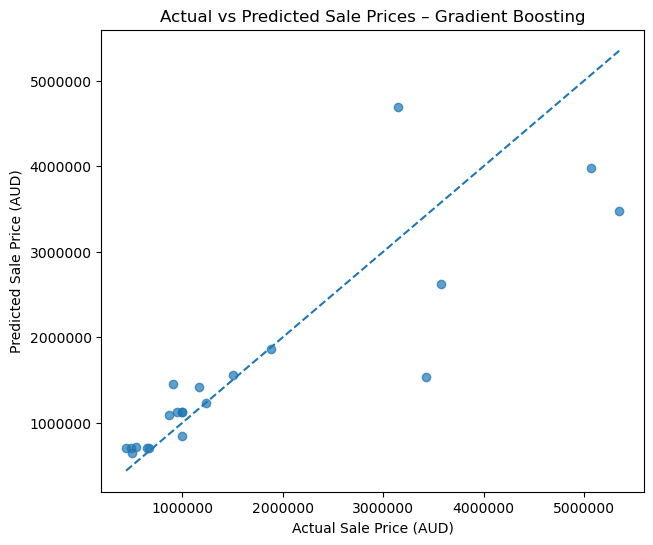

In [194]:
# Actual vs predicted sale prices for the final Gradient Boosting model

best_model = gb_grid.best_estimator_

best_model.fit(X_train, y_train)
gb_test_predictions = best_model.predict(X_test)

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    gb_test_predictions,
    alpha=0.7
)

minimum = min(y_test.min(), gb_test_predictions.min())
maximum = max(y_test.max(), gb_test_predictions.max())

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--"
)

plt.xlabel("Actual Sale Price (AUD)")
plt.ylabel("Predicted Sale Price (AUD)")
plt.title("Actual vs Predicted Sale Prices – Gradient Boosting")

plt.ticklabel_format(style="plain", axis="both")

plt.show()

### 3.2 Model Evaluation and Interpretation

The three regression approaches showed clear differences in predictive performance. In the initial 5-fold cross-validation, Ridge Regression produced the weakest validation results, with an MAE of approximately 455,597 dollars, RMSE of 708,728 dollars and R^2 of 0.585. Its lower performance suggests that the linear model was unable to capture some of the nonlinear relationships and interactions within the housing data, supporting my initial concern that Ridge Regression may underfit the problem.

Random Forest outperformed Ridge Regression by a great margin, giving a cross-validated Mean Absolute Error (MAE) roughly in the range of 375,238 dollars and a Root Mean Squared Error (RMSE) of 622,411 dollars, as well as a R^2 reaching 0.709. Nevertheless, the model having 0.947 R^2 in the training data, is quite a jump compared to what the cross-validation metric shows. Therefore, some degree of overfitting had occurred. Limiting the depth of the trees did not result in a better validation performance either, while the tuning process ended up picking a setting consisting of 200 trees having no restriction on the number of splits.

The default Gradient Boosting model initially showed the clearest evidence of overfitting. It achieved an almost perfect training R^2 of 0.999 but only 0.633 in cross-validation. Increasing tree depth also increased training performance while reducing validation performance, demonstrating that additional complexity did not improve generalisation. Upon tuning, the top Gradient Boosting set-up with the learning rate at 0.03, max depth of a tree being 2, and 100 estimators, decreased the training R^2 to 0.950 while the cross-validation R^2 improved to 0.771. With it also came an improvement in cross-validation MAE and RMSE which were about 347,645 and 541, 678 dollars respectively.



### 3.3 Final Model Evaluation and Recommendation

The tuned Gradient Boosting model achieved the strongest overall cross-validation performance of the three approaches. This supports my original expectation that Gradient Boosting would perform best, although the results also showed that controlling model complexity was important for preventing overfitting.

On the held-out test set, Gradient Boosting again achieved the strongest results, with an MAE of approximately 473,544 dollars, RMSE of 762,283 dollars and R^2 of 0.730. Random Forest achieved an R^2 of 0.660, while Ridge Regression achieved only 0.376. The actual-versus-predicted plot shows that predictions were generally closer to the actual values for lower and moderately priced properties, while several high-value properties produced much larger errors. This is also reflected by the Gradient Boosting RMSE being substantially higher than its MAE.

I determined that the tuned **Gradient Boosting Regression** model was the best fit for this particular problem based on the results of the held-out test and cross-validation. After its complexity was managed, it outperformed the other two methods in terms of generalisation and offered the best overall balance of MAE, RMSE, and R^2. Predictions should still be interpreted cautiously, especially for uncommon or high-value properties, as seen by the still substantial inaccuracies for several premium properties.

# 4. Investigating Prediction Failures


## 4.1 Five Largest Prediction Errors

Investigating where the final Gradient Boosting model performed poorly, I calculated the absolute prediction error for each property in the held-out test set and identified the five properties with the largest errors.

In [201]:
# Creating a table of predictions and errors for the held-out test properties

error_analysis = df.loc[X_test.index, [
    "Property_ID",
    "Address",
    "Suburb",
    "Property_Type",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land_Size_m2",
    "Sale_Price",
    "Property_Description"
]].copy()

# Adding Gradient Boosting predictions
error_analysis["Predicted_Price"] = gb_test_predictions

# Calculating prediction error
error_analysis["Prediction_Error"] = (
    error_analysis["Predicted_Price"] - error_analysis["Sale_Price"]
)

# Calculating absolute error for ranking
error_analysis["Absolute_Error"] = (
    error_analysis["Prediction_Error"].abs()
)

# Sorting from largest to smallest error
top_5_errors = error_analysis.sort_values(
    "Absolute_Error",
    ascending=False
).head(5)

top_5_errors[[
    "Property_ID",
    "Address",
    "Suburb",
    "Property_Type",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Sale_Price",
    "Predicted_Price",
    "Prediction_Error",
    "Absolute_Error"
]].round(2)

,Property_ID,Address,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Sale_Price,Predicted_Price,Prediction_Error,Absolute_Error
43,P044,"37A Sutherland rOAD, Parramatta",Parramatta,Other,12,6,6,3425000,1541296.70,-1883703.30,1883703.30
73,P074,"3 Glen Avenue, Randwick",Randwick,House,5,2,2,5350000,3474120.84,-1875879.16,1875879.16
87,P088,"7 Chiltern Street, Randwick",Randwick,House,3,3,2,3150000,4689492.34,1539492.34,1539492.34
99,P100,"6 Stanley Street, Randwick",Randwick,House,5,3,4,5065000,3984572.69,-1080427.31,1080427.31
79,P080,"3 Carter Street, Randwick",Randwick,House,4,1,2,3575000,2619121.10,-955878.90,955878.90


In [203]:
# Examining the five largest prediction failures in more detail

for _, row in top_5_errors.iterrows():

    print("=" * 90)
    print(f"Property: {row['Property_ID']} - {row['Address']}")
    print(f"Suburb: {row['Suburb']}")
    print(f"Property Type: {row['Property_Type']}")
    print(
        f"Bedrooms: {row['Bedrooms']} | "
        f"Bathrooms: {row['Bathrooms']} | "
        f"Parking: {row['Parking']}"
    )
    print(f"Land Size: {row['Land_Size_m2']} m²")

    print(f"Actual Sale Price: ${row['Sale_Price']:,.0f}")
    print(f"Predicted Price: ${row['Predicted_Price']:,.0f}")
    print(f"Prediction Error: ${row['Prediction_Error']:,.0f}")
    print(f"Absolute Error: ${row['Absolute_Error']:,.0f}")

    print("\nProperty Description:")
    print(row["Property_Description"])

    print()

Property: P044 - 37A Sutherland rOAD, Parramatta
Suburb: Parramatta
Property Type: Other
Bedrooms: 12 | Bathrooms: 6 | Parking: 6
Land Size: 903 m²
Actual Sale Price: $3,425,000
Predicted Price: $1,541,297
Prediction Error: $-1,883,703
Absolute Error: $1,883,703

Property Description:
Rare AAA+ North Parramatta whole block of 6 2-bedroom apartments. Located close to Kings School, Tara Anglican Schools plus other educational universities and institutes. Bus stop within easy walk, providing access into Parramatta CBD and transport interchange

Property: P074 - 3 Glen Avenue, Randwick
Suburb: Randwick
Property Type: House
Bedrooms: 5 | Bathrooms: 2 | Parking: 2
Land Size: 518 m²
Actual Sale Price: $5,350,000
Predicted Price: $3,474,121
Prediction Error: $-1,875,879
Absolute Error: $1,875,879

Property Description:
Meticulously renovated throughout, this immaculate residence is a timeless family sanctuary with elegant interiors evoking an uplifting sense of light and space, framed by tranq

In [205]:
# Calculating percentage errors for the five largest prediction failures

top_5_errors = top_5_errors.copy()

top_5_errors["Absolute_Percentage_Error"] = (
    top_5_errors["Absolute_Error"] / top_5_errors["Sale_Price"] * 100
)

top_5_errors[[
    "Property_ID",
    "Suburb",
    "Property_Type",
    "Sale_Price",
    "Predicted_Price",
    "Prediction_Error",
    "Absolute_Error",
    "Absolute_Percentage_Error"
]].round(2)

,Property_ID,Suburb,Property_Type,Sale_Price,Predicted_Price,Prediction_Error,Absolute_Error,Absolute_Percentage_Error
43,P044,Parramatta,Other,3425000,1541296.70,-1883703.30,1883703.30,55.00
73,P074,Randwick,House,5350000,3474120.84,-1875879.16,1875879.16,35.06
87,P088,Randwick,House,3150000,4689492.34,1539492.34,1539492.34,48.87
99,P100,Randwick,House,5065000,3984572.69,-1080427.31,1080427.31,21.33
79,P080,Randwick,House,3575000,2619121.10,-955878.90,955878.90,26.74


## 4.2 Investigation of the Largest Prediction Failures

The five largest prediction errors ranged from approximately 956,000 dollars to 1.88 million dollars. Four of the five properties were located in Randwick, and four were underpredicted, suggesting that the model had particular difficulty with unusual and high-value properties.

**P044 – 37A Sutherland Road, Parramatta:**  
This property had the largest error. It was underestimated by 1.884 million dollars, or 55.0%, as it sold for 3.425 million dollars instead of the estimated 1.541 million dollars. The description indicates that this property is actually a block of six two-bedroom units, despite the structured data recording 12 bedrooms, 6 bathrooms, and 6 parking spaces. It differs greatly from a typical residential property because of this. My small dataset contained relatively few comparable observations, which made it challenging for the model to determine the appropriate value for a whole apartment complex.

**P074 – 3 Glen Avenue, Randwick:**  
This five-bedroom home was undervalued by 1.876 million dollars, or 35.1%, as it sold for 5.350 million dollars instead of the estimated 3.474 million dollars. Features like substantial renovations, views of the ocean horizon, and a prime position near beaches, Randwick Village, and the light rail are all mentioned in the description. Although some of these ideas were represented by my binary description features, the model could not fully represent the quality of the renovation, views or exact location. These factors may help explain why the property's premium value was underestimated.

**P088 – 7 Chiltern Street, Randwick:**  
This property sold for 3.150 million dollars but was predicted at approximately 4.689 million dollars, an overprediction of 1.539 million dollars or 48.9%. One unusual characteristic is its recorded land size of 5,478 m^2, which is extremely large compared with most houses in the dataset. Since house land size was included as a predictor, this extreme value may have contributed to the high prediction. This case also highlights the importance of data quality and the difficulty of modelling unusual numerical observations.

**P100 – 6 Stanley Street, Randwick:**  
This property was undervalued by 1.080 million dollars, or 21.3%, as it sold for 5.065 million dollars instead of the estimated 3.985 million dollars. The description claims that it is actually a collection of three Art Deco flats, though it was registered as a home with five bedrooms, three bathrooms, and four parking spaces. The structured variables therefore do not fully represent the nature of the property. Its unusual dwelling structure and prized North Randwick location make it difficult to compare with typical houses in the training data.

**P080 – 3 Carter Street, Randwick:**  
This four-bedroom house sold for 3.575 million dollars but was predicted at approximately 2.619 million dollars, an underprediction of 956,000 dollars or 26.7%. The description highlights features such as its Federation character, north-east aspect, elevated setting, dual access, development potential and tightly held North Randwick location. These detailed qualitative characteristics are difficult to represent using the limited structured features available to the model and may have contributed to the underprediction.

## 4.3 Model Limitations and When Predictions Should Be Used Cautiously

The five largest errors highlighted several limitations of my modelling approach. One of the main limitations is the small dataset of only 105 properties. Although the dataset represents three different housing markets, there are relatively few examples of unusual or very expensive properties for the model to learn from. This was particularly noticeable in Randwick, which accounted for four of the five largest prediction errors.

Another limitation is that the structured predictors cannot fully describe the characteristics that influence the value of a property. Important information such as exact street location, views, architectural style, condition, quality of renovations, aspect and proximity to specific amenities was either unavailable or only partly represented through the description-based indicators. More detailed location information, such as distance to the CBD, beaches, schools and public transport, as well as property floor area and more reliable land measurements, may improve future predictions.

The failure analysis also showed that some properties are inherently more difficult to model. P044 was a whole block of six apartments, while P100 was a collection of three Art Deco apartments, even though their structured features represented them using aggregated bedroom, bathroom and parking counts. These properties do not fit neatly into the usual house, unit or townhouse categories and have few comparable observations in the dataset.

I would therefore interpret predictions cautiously for high-value properties, unusual multi-dwelling properties, properties with extreme feature values, and properties whose value depends heavily on characteristics that are not captured by the model. The model is more suitable as a decision-support tool than as a replacement for professional valuation or detailed market research. Its prediction can provide an estimate, but the individual property context should still be considered before making a purchasing decision.

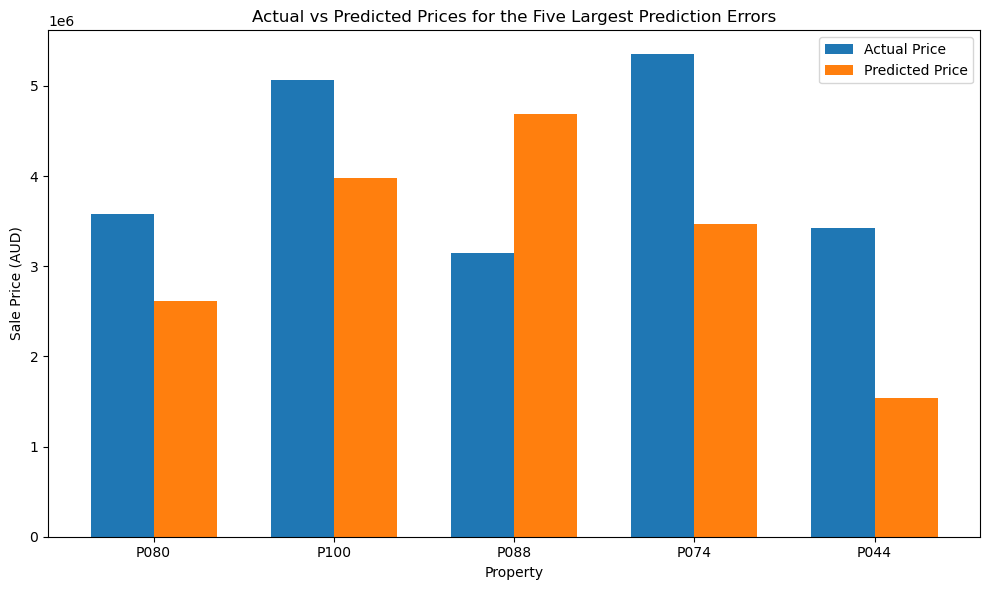

In [209]:
# Visualising the five largest prediction errors

import matplotlib.pyplot as plt
import numpy as np

plot_data = top_5_errors.sort_values("Absolute_Error")

x = np.arange(len(plot_data))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width/2,
    plot_data["Sale_Price"],
    width,
    label="Actual Price"
)

plt.bar(
    x + width/2,
    plot_data["Predicted_Price"],
    width,
    label="Predicted Price"
)

plt.xticks(x, plot_data["Property_ID"])
plt.xlabel("Property")
plt.ylabel("Sale Price (AUD)")
plt.title("Actual vs Predicted Prices for the Five Largest Prediction Errors")
plt.legend()

plt.tight_layout()
plt.show()

### Prediction Failure Summary

The five largest errors show that the model had greater difficulty with unusual and premium properties. Four of the five largest errors were underpredictions, and four occurred in Randwick. P044 and P100 also represented unusual multi-dwelling sales that were not adequately described by the standard structured property features. P088 was the only major overprediction and also contained an unusually large recorded land-size value. Overall, these results suggest that the model performs less reliably when a property differs substantially from the more typical observations available during training.

# 5. Human Judgement, Machine Learning, and Large Language Models



## 5.1 Selection of Properties

For this comparison, I selected 10 properties from the held-out test set using a fixed random sample. These properties were not used to train the final model. I used the same basic property information when making the machine learning, large language model and human estimates so that the three approaches could be compared fairly.

In [214]:
# Selecting 10 properties from the held-out test set
# A fixed random state makes the selection reproducible

comparison_indices = X_test.sample(
    n=10,
    random_state=42
).index

comparison_properties = df.loc[comparison_indices, [
    "Property_ID",
    "Suburb",
    "Property_Type",
    "Bedrooms",
    "Bathrooms",
    "Parking",
    "Land_Size_m2",
    "Property_Description"
]].copy()

comparison_properties

,Property_ID,Suburb,Property_Type,Bedrooms,Bathrooms,Parking,Land_Size_m2,Property_Description
79,P080,Randwick,House,4,1,2,308,"308sqm North East aspect, private elevated set..."
28,P029,Blacktown,Unit,2,2,1,111,"Presented by Ray White Blacktown, this modern ..."
20,P021,Blacktown,House,4,2,6,556,Andrew Ienna is proud to present 6 Garden Stre...
83,P084,Randwick,Unit,1,1,0,62,Art Deco charm meets urban convenience in this...
87,P088,Randwick,House,3,3,2,5478,"Perfectly positioned in a quiet, tree-lined st..."
14,P015,Blacktown,House,3,2,0,556,"Positioned in a quiet and convenient location,..."
38,P039,Parramatta,Unit,2,2,1,108,Positioned in a sought-after riverside setting...
99,P100,Randwick,House,5,3,4,415,Surrounded by sandstone fencing and towering t...
55,P056,Parramatta,Unit,2,1,1,1411,Situated just a short stroll from Parramatta's...
6,P007,Blacktown,House,6,3,8,817,Calling all large or extended families and ast...


In [216]:
# Generating Gradient Boosting predictions for the 10 selected properties

X_comparison = X_test.loc[comparison_indices]

ml_predictions = final_models["Gradient Boosting"].predict(X_comparison)

comparison_results = comparison_properties[
    [
        "Property_ID",
        "Suburb",
        "Property_Type",
        "Bedrooms",
        "Bathrooms",
        "Parking"
    ]
].copy()

comparison_results["ML_Prediction"] = ml_predictions

comparison_results[
    ["Property_ID", "Suburb", "Property_Type", "ML_Prediction"]
].round(2)

,Property_ID,Suburb,Property_Type,ML_Prediction
79,P080,Randwick,House,2619121.10
28,P029,Blacktown,Unit,704391.46
20,P021,Blacktown,House,1237245.45
83,P084,Randwick,Unit,1096768.35
87,P088,Randwick,House,4689492.34
14,P015,Blacktown,House,1127485.09
38,P039,Parramatta,Unit,719318.45
99,P100,Randwick,House,3984572.69
55,P056,Parramatta,Unit,709066.66
6,P007,Blacktown,House,1865243.94


In [218]:
# Preparing property information for LLM valuation

for _, row in comparison_properties.iterrows():
    print("=" * 80)
    print(f"Property ID: {row['Property_ID']}")
    print(f"Suburb: {row['Suburb']}")
    print(f"Property Type: {row['Property_Type']}")
    print(f"Bedrooms: {row['Bedrooms']}")
    print(f"Bathrooms: {row['Bathrooms']}")
    print(f"Parking: {row['Parking']}")
    print(f"Land Size: {row['Land_Size_m2']} m²")
    print(f"Description: {row['Property_Description']}")
    print()

Property ID: P080
Suburb: Randwick
Property Type: House
Bedrooms: 4
Bathrooms: 1
Parking: 2
Land Size: 308 m²
Description: 308sqm North East aspect, private elevated setting and sunny dual access block combine in this grand Federation semi to present a prime opportunity in a tightly held pocket of Randwick North. Offering exceptional scale, light and untapped potential on over 300sqm, the 8m fronted double-storey classic has been held by one family for 64 years with its authentic period charm shining bright and northerly district views enhancing the sense of peace and privacy. On the high side of a quiet street where homes rarely trade, the location is superb, around the corner from Clovelly Road's cafe scene and 450m to Queens Park and the Musgrave Avenue gates to Centennial Park. With leading schools, village hubs and a choice of beaches close at hand, this is a generational opportunity to secure a substantial family home and shape its next chapter with plenty of room and level rear 

### 5.2 Large Language Model Estimates

I used ChatGPT as the large language model for this comparison. I provided the LLM with the suburb, property type, number of bedrooms and bathrooms, parking, land size and property description for each of the 10 properties. The actual sale prices and machine learning predictions were not provided when the LLM estimates were generated.

In [221]:
# LLM sale price estimates based only on the supplied property information

llm_estimates = {
    "P080": 3400000,
    "P029": 650000,
    "P021": 1200000,
    "P084": 850000,
    "P088": 3300000,
    "P015": 950000,
    "P039": 720000,
    "P100": 4200000,
    "P056": 620000,
    "P007": 1500000
}

comparison_results["LLM_Prediction"] = (
    comparison_results["Property_ID"].map(llm_estimates)
)

comparison_results[
    ["Property_ID", "Suburb", "Property_Type",
     "ML_Prediction", "LLM_Prediction"]
].round(2)

,Property_ID,Suburb,Property_Type,ML_Prediction,LLM_Prediction
79,P080,Randwick,House,2619121.10,3400000
28,P029,Blacktown,Unit,704391.46,650000
20,P021,Blacktown,House,1237245.45,1200000
83,P084,Randwick,Unit,1096768.35,850000
87,P088,Randwick,House,4689492.34,3300000
14,P015,Blacktown,House,1127485.09,950000
38,P039,Parramatta,Unit,719318.45,720000
99,P100,Randwick,House,3984572.69,4200000
55,P056,Parramatta,Unit,709066.66,620000
6,P007,Blacktown,House,1865243.94,1500000


### 5.3 My Own Estimates

I estimated the sale prices myself using what I had learned while collecting and exploring the housing data. I mainly considered the suburb, property type, number of bedrooms and bathrooms, land size and the information provided in the property description. I also used patterns I remembered from the dataset, such as Randwick properties generally being more expensive. I made these estimates without looking at the actual sale prices for the selected test properties.

In [223]:
# My own sale price estimates based on my understanding of the dataset

human_estimates = {
    "P080": 3000000,
    "P029": 140000,
    "P021": 2000000,
    "P084": 500000,
    "P088": 3000000,
    "P015": 1000000,
    "P039": 200000,
    "P100": 4000000,
    "P056": 160000,
    "P007": 2000000
}

comparison_results["Human_Estimate"] = (
    comparison_results["Property_ID"].map(human_estimates)
)

comparison_results[
    [
        "Property_ID",
        "Suburb",
        "Property_Type",
        "ML_Prediction",
        "LLM_Prediction",
        "Human_Estimate"
    ]
].round(2)

,Property_ID,Suburb,Property_Type,ML_Prediction,LLM_Prediction,Human_Estimate
79,P080,Randwick,House,2619121.10,3400000,3000000
28,P029,Blacktown,Unit,704391.46,650000,140000
20,P021,Blacktown,House,1237245.45,1200000,2000000
83,P084,Randwick,Unit,1096768.35,850000,500000
87,P088,Randwick,House,4689492.34,3300000,3000000
14,P015,Blacktown,House,1127485.09,950000,1000000
38,P039,Parramatta,Unit,719318.45,720000,200000
99,P100,Randwick,House,3984572.69,4200000,4000000
55,P056,Parramatta,Unit,709066.66,620000,160000
6,P007,Blacktown,House,1865243.94,1500000,2000000


### 5.4 Adding Actual Sale Prices and Calculate Errors

In [228]:
# Adding the actual sale prices for the 10 held-out properties

comparison_results["Actual_Price"] = y_test.loc[comparison_results.index]

# Calculating absolute errors for each approach
comparison_results["ML_Error"] = abs(
    comparison_results["Actual_Price"] - comparison_results["ML_Prediction"]
)

comparison_results["LLM_Error"] = abs(
    comparison_results["Actual_Price"] - comparison_results["LLM_Prediction"]
)

comparison_results["Human_Error"] = abs(
    comparison_results["Actual_Price"] - comparison_results["Human_Estimate"]
)

comparison_results[
    [
        "Property_ID",
        "Actual_Price",
        "ML_Prediction",
        "LLM_Prediction",
        "Human_Estimate",
        "ML_Error",
        "LLM_Error",
        "Human_Error"
    ]
].round(2)

,Property_ID,Actual_Price,ML_Prediction,LLM_Prediction,Human_Estimate,ML_Error,LLM_Error,Human_Error
79,P080,3575000,2619121.10,3400000,3000000,955878.90,175000,575000
28,P029,440000,704391.46,650000,140000,264391.46,210000,300000
20,P021,1235000,1237245.45,1200000,2000000,2245.45,35000,765000
83,P084,865000,1096768.35,850000,500000,231768.35,15000,365000
87,P088,3150000,4689492.34,3300000,3000000,1539492.34,150000,150000
14,P015,1000000,1127485.09,950000,1000000,127485.09,50000,0
38,P039,540000,719318.45,720000,200000,179318.45,180000,340000
99,P100,5065000,3984572.69,4200000,4000000,1080427.31,865000,1065000
55,P056,485000,709066.66,620000,160000,224066.66,135000,325000
6,P007,1881000,1865243.94,1500000,2000000,15756.06,381000,119000


### 5.5 Comparing Overall Performance

In [231]:
# Comparing the overall performance of ML, LLM and my own estimates

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

comparison_metrics = []

approaches = {
    "Machine Learning": "ML_Prediction",
    "Large Language Model": "LLM_Prediction",
    "Human Estimate": "Human_Estimate"
}

for approach, column in approaches.items():
    mae = mean_absolute_error(
        comparison_results["Actual_Price"],
        comparison_results[column]
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            comparison_results["Actual_Price"],
            comparison_results[column]
        )
    )
    
    comparison_metrics.append({
        "Approach": approach,
        "MAE": mae,
        "RMSE": rmse
    })

comparison_metrics_df = pd.DataFrame(comparison_metrics)

comparison_metrics_df.round(2)

,Approach,MAE,RMSE
0,Machine Learning,462083.01,683633.71
1,Large Language Model,219600.00,323293.37
2,Human Estimate,400400.00,503108.93


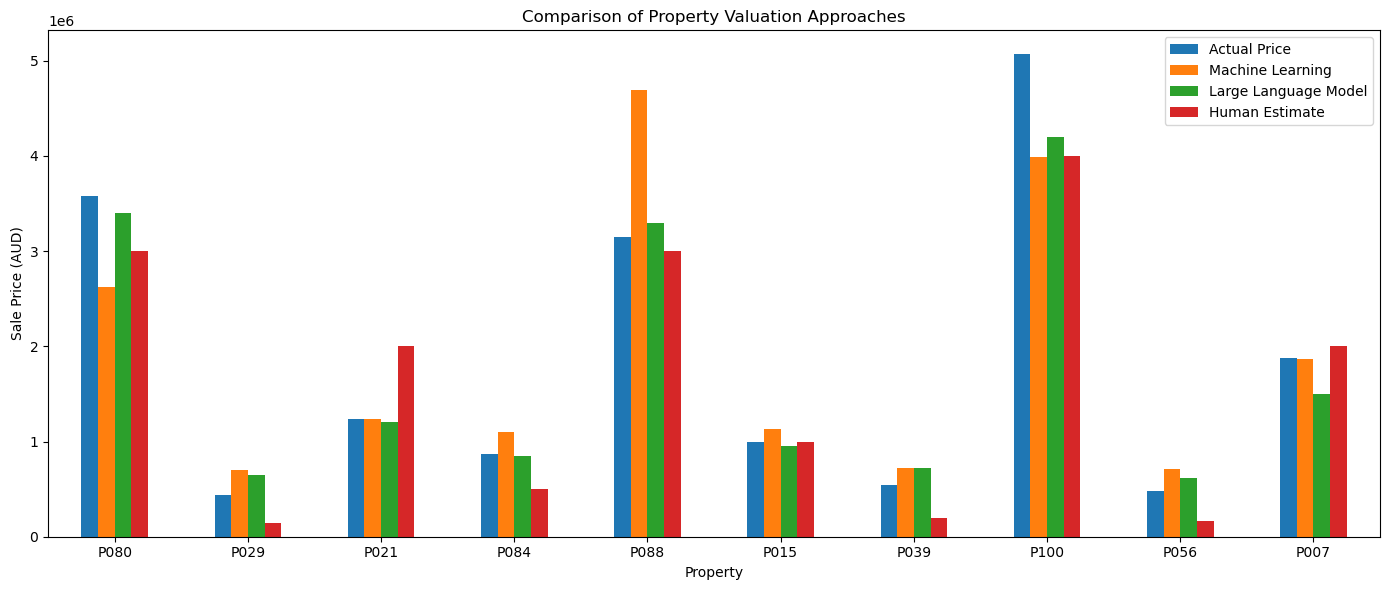

In [233]:
# Visual comparison of actual prices and the three prediction approaches

plot_data = comparison_results[
    [
        "Property_ID",
        "Actual_Price",
        "ML_Prediction",
        "LLM_Prediction",
        "Human_Estimate"
    ]
].set_index("Property_ID")

plot_data.plot(
    kind="bar",
    figsize=(14, 6)
)

plt.title("Comparison of Property Valuation Approaches")
plt.xlabel("Property")
plt.ylabel("Sale Price (AUD)")
plt.xticks(rotation=0)
plt.legend([
    "Actual Price",
    "Machine Learning",
    "Large Language Model",
    "Human Estimate"
])
plt.tight_layout()
plt.show()

### 5.5 Comparison and Discussion

For the ten selected test properties, the large language model performed best overall. It achieved an MAE of 219,600 dollars and an RMSE of 323,293 dollars, compared with 400,400 dollars and 503,109 dollars for my own estimates and 462,083 dollars and 683,634 dollars for the machine learning model. I found this result interesting because Gradient Boosting was the strongest model during the earlier model evaluation, but it was not the most accurate approach for this smaller comparison.

Looking at the individual properties helped explain these results. The LLM was particularly accurate for P084, where it estimated 850,000 dollars compared with the actual price of 865,000 dollars, and P080, where its estimate of 3.4 million dollars was close to the actual 3.575 million dollars. My own estimates were less consistent, although I estimated P015 exactly at its actual sale price of 1 million dollars. I also came reasonably close for P007 and P088. My estimates were much weaker for some of the lower-priced units, particularly P029, P039 and P056, showing that my judgement was less reliable across different parts of the market.

The machine learning model performed well for some more typical properties. For example, its predictions for P021 and P007 were very close to their actual prices. However, it struggled with unusual or high-value properties. The clearest example was P088, where the actual price was 3.15 million dollars but the model predicted approximately 4.69 million dollars. This is consistent with the prediction failures identified in Part 4 and shows how unusual property characteristics can cause problems for a model trained on a relatively small dataset.

One possible advantage of the LLM in this comparison was that it could interpret the full property descriptions. These descriptions contained contextual information about renovation, location, nearby amenities, property character and other features that were only represented more simply in the machine learning model. However, the LLM was not trained specifically on my dataset and its estimates may also be influenced by general knowledge or assumptions about the Sydney property market. Therefore, its strong performance on these ten properties should not be interpreted as evidence that it would always outperform the trained model.

I still think human judgement contributes value to this type of task. While my estimates were not the most accurate overall, I was able to use knowledge gained while collecting and exploring the data, such as recognising that Randwick houses generally belonged to a much higher price range. Human judgement can also recognise when a property appears unusual and when a model prediction should be treated cautiously. However, my results also demonstrate that personal judgement can be inconsistent and affected by limited market knowledge.

Overall, each approach had different strengths. The machine learning model provided a consistent and reproducible data-driven method, the LLM was able to interpret richer contextual information from the descriptions, and human judgement provided contextual reasoning but was more subjective. For this ten-property comparison, the LLM produced the most accurate estimates, but I would not rely on any of the three approaches alone for a real property valuation.

# 6. Final Deployment and Reflection


### 6.1 Web Application Development

To make the final housing price prediction model usable outside the Jupyter Notebook, I developed a simple web-based application using Streamlit. The application allows a user to enter property characteristics and receive an estimated sale price from the final Gradient Boosting model selected in Part 3.

The deployed application uses the same trained machine learning pipeline used during model evaluation. The complete fitted pipeline is saved using `joblib`, allowing the preprocessing steps and trained Gradient Boosting model to be loaded directly by the application. This helps ensure that new property data is processed consistently with the data used during model development.

The following steps show the process of saving the final model, developing the Streamlit application, and testing the application.

In [238]:
# Saving the final Gradient Boosting model for deployment

import joblib

final_gradient_boosting = final_models["Gradient Boosting"]

# Making sure the final model is fitted using all training data
final_gradient_boosting.fit(X_train, y_train)

joblib.dump(
    final_gradient_boosting,
    "gradient_boosting_housing_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [242]:
# Creating the Streamlit application file

app_code = '''
import streamlit as st
import pandas as pd
import joblib

# Load the trained Gradient Boosting pipeline
model = joblib.load("gradient_boosting_housing_model.pkl")

st.set_page_config(
    page_title="Sydney Housing Price Predictor",
    page_icon="🏡",
    layout="centered"
)

st.title(" 🏡 Sydney Housing Price Predictor")

st.write(
    "Enter the property details below to estimate its sale price "
    "using the Gradient Boosting model developed in this project."
)

suburb = st.selectbox(
    "Suburb",
    ["Blacktown", "Parramatta", "Randwick"]
)

property_type = st.selectbox(
    "Property Type",
    ["House", "Unit", "Townhouse", "Other"]
)

bedrooms = st.number_input(
    "Bedrooms", min_value=1, max_value=12, value=3, step=1
)

bathrooms = st.number_input(
    "Bathrooms", min_value=1, max_value=6, value=2, step=1
)

parking = st.number_input(
    "Parking Spaces", min_value=0, max_value=8, value=1, step=1
)

land_size = st.number_input(
    "Land Size (m²)", min_value=0.0, value=500.0, step=10.0
)

days_since_first_sale = st.number_input(
    "Days Since First Sale in Dataset",
    min_value=0,
    max_value=315,
    value=250,
    step=1
)

st.subheader("Property Description Features")

near_transport = st.checkbox("Near transport")
near_school = st.checkbox("Near school")
near_shops = st.checkbox("Near shops")
near_park = st.checkbox("Near park")
renovated = st.checkbox("Renovated")
development_potential = st.checkbox("Development potential")
granny_flat = st.checkbox("Granny flat")
premium_feature = st.checkbox("Premium feature")

if st.button("Predict Sale Price"):

    # Land size is used as individual land area only for houses
    house_land_size = land_size if property_type == "House" else 0

    total_rooms = bedrooms + bathrooms

    input_data = pd.DataFrame({
        "Bedrooms": [bedrooms],
        "Bathrooms": [bathrooms],
        "Parking": [parking],
        "Days_Since_First_Sale": [days_since_first_sale],
        "House_Land_Size_m2": [house_land_size],
        "Total_Rooms": [total_rooms],
        "Near_Transport": [int(near_transport)],
        "Near_School": [int(near_school)],
        "Near_Shops": [int(near_shops)],
        "Near_Park": [int(near_park)],
        "Renovated": [int(renovated)],
        "Development_Potential": [int(development_potential)],
        "Granny_Flat": [int(granny_flat)],
        "Premium_Feature": [int(premium_feature)],
        "Suburb": [suburb],
        "Property_Type": [property_type]
    })

    prediction = model.predict(input_data)[0]

    st.success(f"Estimated Sale Price: ${prediction:,.0f}")

st.caption(
    "This prediction is an estimate based on the limited housing dataset "
    "used in this project and should not be treated as a professional property valuation."
)
'''

with open("app.py", "w", encoding="utf-8") as file:
    file.write(app_code)

print("app.py created successfully.")

app.py created successfully.


In [244]:
import streamlit as st

print("Streamlit is installed.")
print("Version:", st.__version__)

Streamlit is installed.
Version: 1.32.0


### 6.2 Running and Using the Application

I implemented the web application using Streamlit and saved as `app.py`. The trained Gradient Boosting pipeline was saved as `gradient_boosting_housing_model.pkl` using `joblib`, allowing the application to load the same model and preprocessing pipeline used during model development.

To run the application locally, I opened a terminal in the project directory and used:

`streamlit run app.py`

Streamlit then launched the application in a web browser through a local address. The application allows the user to select the suburb and property type and enter the number of bedrooms, bathrooms, parking spaces, land size and the property's position within the dataset time period. The user can also select description-based characteristics such as proximity to transport, schools, shops and parks, renovation status, development potential, granny flat availability and premium features.

After entering the property information, the user clicks **Predict Sale Price**. The application converts the inputs into the same feature structure used during model training and passes them through the saved Gradient Boosting pipeline. The resulting estimated sale price is then displayed in Australian dollars.

As a test of the application, a property was entered and the model returned an estimated sale price of **1,127,485 dollars**. A disclaimer is also displayed to make it clear that the result is an estimate based on the limited dataset used in this project and should not be considered a professional property valuation.


### 6.3 Critical Reflection

This project gave me experience with the complete machine learning workflow, from manually collecting housing data through to deploying a working prediction application. One of the main lessons I learned was that the quality and interpretation of the data can be just as important as the choice of machine learning model. Collecting the dataset manually was time-consuming, and information was not always presented consistently across properties. A particularly important example was land size. For some units, the reported land size appeared to represent the overall strata or site area rather than the individual apartment. Instead of changing these values without evidence, I retained the original data and created `House_Land_Size_m2` so that land size could be interpreted more consistently for houses.

Feature engineering also showed me how unstructured information can provide additional useful information. The property descriptions contained details relating to transport, schools, shops, parks, renovations, development potential and other property characteristics that were not represented by the original numerical variables. I converted these into binary indicators. However, these features also have limitations because property advertisements are written for marketing purposes, and the absence of a feature from a description does not necessarily mean that the property does not have that characteristic.

During model development, I learned that a more complex model does not automatically guarantee accurate predictions for every property. Although Gradient Boosting provided the strongest overall performance and was selected as the final model, the prediction failure analysis showed that substantial errors still occurred, particularly for unusual and high-value properties. The dataset contained only 105 properties from three suburbs, meaning that rare property characteristics and the upper end of the housing market were represented by relatively few observations. Important factors such as exact street location, property condition, internal floor area, views, renovation quality, proximity to specific amenities and market conditions were also unavailable or only partially represented.

Deploying the model with Streamlit demonstrated the trade-off between predictive performance and practical usability. Saving the complete trained pipeline allowed the same preprocessing and Gradient Boosting model to be used by the application. The final interface allows users to enter property characteristics and receive an estimated sale price without interacting with Python code. However, making the model accessible through a simple interface does not remove its underlying limitations. A prediction that appears precise in the application is still based on a relatively small and limited dataset and should not be interpreted as a professional property valuation.

There are also ethical and fairness considerations when using automated property valuation. The model learns patterns from historical sales, so existing differences between suburbs and property types can be reproduced in its predictions. The small dataset may not represent the full diversity of the Sydney housing market, and properties or locations that are poorly represented may receive less reliable predictions. Automated estimates could therefore be misleading if used as the sole basis for important financial decisions.

If I extended this project, I would collect substantially more sales across a longer time period and a wider range of Sydney suburbs. I would also include more detailed location and property information, such as geographic coordinates, distance to transport and schools, internal floor area, property age and condition. With more data, I could investigate more advanced modelling and natural language processing of property descriptions and perform more extensive hyperparameter optimisation. Overall, this project showed me that a useful machine learning system requires not only good predictive performance, but also careful data collection, interpretation, evaluation and an understanding of when its predictions should and should not be trusted.